# 4x4 Macro OCRP — Twin / Thin-Lamella Failure Probe

**Goal:** demystify, with end-to-end measurement, why the trained 4x4 macro OCRP model reproduces large grains cleanly but fails on thin twin lamellae.

**Competing hypotheses to test, not assume:**

1. **Slot-allocation bottleneck.** The macro-tile pipeline only keeps the top `kmax_slots=6` clusters from each 9x9 LR support window, so thin twins may be deleted before the router ever sees them.
2. **Router bottleneck.** The twin cluster often survives, but the router still sends HR tokens to the wrong surviving slot.

The notebook is designed to decide between those two explanations with direct tensor-level evidence.

We will measure, per HR pixel that belongs to a thin connected component on the ground-truth HR map:
1. The LR cluster id it falls into for its macro-tile's 9x9 support window.
2. Whether that cluster survived the top-K cut into `slot_cluster_label`.
3. If so, whether the router's `argmax` actually routed the HR pixel to that surviving slot.
4. Whether router errors concentrate in low-rank slots that survive but are effectively starved.
5. Whether an explicit geometry prior over slot ownership fixes the routing problem without changing the slot allocator.

Two guardrails before interpreting the results:
- The thin-feature detector below is a **proxy for thin twins**, not an explicit crystallographic twin labeler.
- The notebook's job is to identify the **dominant bottleneck in the trained checkpoint**, not to prove that all downstream stages are irrelevant in every sample.


## 1 - Imports and repo setup

In [70]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

_HERE = Path.cwd()
for candidate in [_HERE, *_HERE.parents]:
    if (candidate / 'models' / 'SR_ocrp.py').exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate repo root from ' + str(_HERE))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Repo root:', REPO_ROOT)

from inference.infer_iso_embedding_sr_attn import (
    _flatten_quat_chw,
    _load_model_from_checkpoint,
    _resolve_checkpoint,
    _to_hwc_quat_single,
    _unpack_batch,
)
from models.SR_ocrp import (
    IsoEmbeddingSROCRP,
    _left_mult_matrix_wxyz_batch,
    _misorientation_angle_sym,
    _normalize_quaternions,
)
from training.config_utils import load_and_prepare_config
from training.data_loading import build_dataloader
from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb

EXP_DIR = REPO_ROOT / 'experiments' / 'IN718' / 'iso_embedding_4x4_ocrp_macro_01'
CFG_PATH = EXP_DIR / 'config_new.json'
CKPT_NAME = 'best_model.pt'
SPLIT = 'Val'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Experiment:', EXP_DIR)
print('Device:', DEVICE)

Repo root: /data/home/umang/Materials/Reynolds-QSR_4x1
Experiment: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_4x4_ocrp_macro_01
Device: cuda


## 2 - Load model and one validation sample
We keep `num_workers=0` and `take_first` small so the notebook starts cheap. Later cells aggregate across more samples.

In [71]:
cfg = load_and_prepare_config(CFG_PATH, EXP_DIR / 'logs' / 'twin_probe_run_config.json')
ckpt_path = _resolve_checkpoint(cfg, EXP_DIR, CKPT_NAME)
model = _load_model_from_checkpoint(cfg, ckpt_path, device=DEVICE)
model.eval()
assert isinstance(model, IsoEmbeddingSROCRP), f'Expected OCRP model, got {type(model).__name__}'
assert model.ocrp.ocrp_mode == 'macro_tile', f'Expected macro_tile mode, got {model.ocrp.ocrp_mode}'

WINDOW = int(model.ocrp.window_size)
TILE   = int(model.ocrp.macro_lr_tile_size)
K_MAX  = int(model.ocrp.kmax_slots)
UPS_H, UPS_W = model.ocrp.upsample_factor
PATCH_H, PATCH_W = model.ocrp.hr_patch_shape
print(f'window={WINDOW}, tile={TILE}, kmax={K_MAX}, ups={UPS_H}x{UPS_W}, hr_patch={PATCH_H}x{PATCH_W}')
print(f'#nodes per support = {WINDOW*WINDOW},  #tokens per HR patch = {PATCH_H*PATCH_W}')

Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 2 (default: 4)
  - symmetry_group: Oh (default: O)
  - use_amp: True (default: False)
  - decoder_steps: 60 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - save_every: 10 (default: 5)
  - viz_every: 1 (default: 5)
  - viz_sample_key: x_230 (default: None)
  - num_workers: 8 (default: 0)
  - persistent_workers: True (default: False)
  - prefetch_factor: 4 (default: 2)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - cudnn_benchmark: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_ocrp (default: iso_embedding_sr_attn)
  - logging.val_freq: 10 (default: 1)
Using existing symmetry files for Oh
Saved resolved config to /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_4x4_ocrp_ma

In [72]:
SAMPLE_IDX = 0
loader = build_dataloader(
    dataset_root=cfg.dataset_root, split=SPLIT, batch_size=1, shuffle=False,
    num_workers=0, preload=False, preload_torch=False, pin_memory=False,
    take_first=SAMPLE_IDX + 1, seed=int(getattr(cfg, 'seed', 42)),
)
for idx, batch in enumerate(loader):
    if idx == SAMPLE_IDX:
        break
lr_b, hr_b, _ = _unpack_batch(batch)
lr = lr_b[0].to(DEVICE, dtype=torch.float32)
hr = hr_b[0].to(DEVICE, dtype=torch.float32)
lr_flat, lr_shape = _flatten_quat_chw(lr)
lr_hwc = _to_hwc_quat_single(lr).detach().cpu()
hr_hwc = _to_hwc_quat_single(hr).detach().cpu()
print(f'LR: {tuple(lr_hwc.shape)}, HR: {tuple(hr_hwc.shape)}')

LR: (64, 64, 4), HR: (256, 256, 4)


In [73]:
with torch.no_grad():
    feat_lr = model.encode(lr_flat)
    feat_hr, hr_shape, aux = model._forward_sr_features(
        lr_quats=lr_flat, feat_lr=feat_lr, lr_shape=lr_shape, return_aux=True,
    )
# decoder runs internal Adam refinement -> needs grad enabled
# (input is detach()-ed inside the decoder, so no upstream graph is built)
with torch.enable_grad():
    sr_flat = model.decode(feat_hr)
sr_hwc = sr_flat.reshape(int(hr_shape[0]), int(hr_shape[1]), 4).detach().cpu()

def _unbatch(x):
    if isinstance(x, torch.Tensor) and x.dim() > 0 and x.shape[0] == 1:
        return x[0]
    return x
aux = {k: _unbatch(v) for k, v in aux.items()}
GRID_H, GRID_W = (int(v) for v in aux['support_grid_shape'])
HR_H, HR_W = (int(v) for v in hr_shape)
N_TILES = GRID_H * GRID_W
print(f'support_grid_shape: {GRID_H}x{GRID_W}  ({N_TILES} macro tiles)')
print(f'hr_shape          : {HR_H}x{HR_W}')
print('aux tensors:')
for k in ['cluster_ids', 'slot_mask', 'slot_valid', 'slot_meta', 'owner_idx', 'router_logits', 'bank_q']:
    if k in aux and isinstance(aux[k], torch.Tensor):
        print(f'  {k:>14s}: {tuple(aux[k].shape)}')

support_grid_shape: 22x22  (484 macro tiles)
hr_shape          : 256x256
aux tensors:
     cluster_ids: (484, 81)
       slot_mask: (484, 6, 81)
      slot_valid: (484, 6)
       slot_meta: (484, 6, 11)
       owner_idx: (484, 144)
   router_logits: (484, 144, 6)
          bank_q: (484, 81, 4)


## 3 - Visual context: LR / SR / HR triplet (IPF-X)

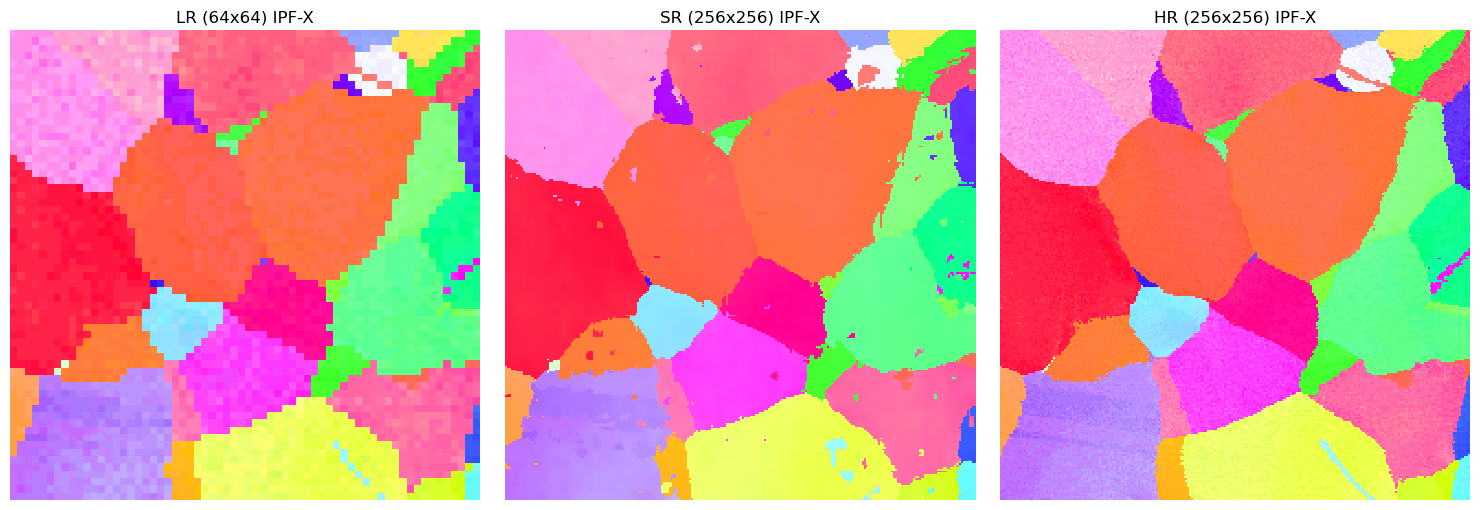

In [74]:
sym_class = resolve_symmetry(getattr(cfg, 'symmetry_group', 'Oh'))

def ipf_x(q_hwc):
    return render_ipf_rgb(q_hwc.numpy().astype(np.float32), sym_class, ref_dir='X')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, q, label in zip(axes, [lr_hwc, sr_hwc, hr_hwc], ['LR', 'SR', 'HR']):
    ax.imshow(ipf_x(q), interpolation='nearest')
    ax.set_title(f'{label} ({q.shape[0]}x{q.shape[1]}) IPF-X')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4 - Identify thin features on the HR ground truth
We run the same connected-components logic the model uses on the LR support, but on the **full HR map**, with the same 2 deg threshold under crystal symmetry. Components below an area cap are flagged as *thin features* (twin candidates in IN718).

In [75]:
@torch.no_grad()
def grid_components(quats_hw4, sym_ops_quat, threshold_deg=2.0, connectivity=8, miso_chunk=200_000):
    H, W, _ = quats_hw4.shape
    flat = _normalize_quaternions(quats_hw4.reshape(-1, 4).to(torch.float32))
    sym_mat = _left_mult_matrix_wxyz_batch(_normalize_quaternions(sym_ops_quat.detach().cpu()))
    threshold_rad = float(np.deg2rad(threshold_deg))
    ys = torch.arange(H).view(-1, 1).expand(H, W).reshape(-1)
    xs = torch.arange(W).view(1, -1).expand(H, W).reshape(-1)
    idx = (ys * W + xs)
    pairs_a, pairs_b = [], []
    if W > 1:
        m = xs < (W - 1); pairs_a.append(idx[m]); pairs_b.append(idx[m] + 1)
    if H > 1:
        m = ys < (H - 1); pairs_a.append(idx[m]); pairs_b.append(idx[m] + W)
    if connectivity == 8 and H > 1 and W > 1:
        m = (xs < (W - 1)) & (ys < (H - 1)); pairs_a.append(idx[m]); pairs_b.append(idx[m] + W + 1)
        m = (xs > 0) & (ys < (H - 1));        pairs_a.append(idx[m]); pairs_b.append(idx[m] + W - 1)
    ea = torch.cat(pairs_a); eb = torch.cat(pairs_b)
    keep_chunks = []
    for s in range(0, ea.numel(), miso_chunk):
        e = min(s + miso_chunk, ea.numel())
        m = _misorientation_angle_sym(flat[ea[s:e]], flat[eb[s:e]], sym_mat)
        keep_chunks.append(m <= threshold_rad)
    keep = torch.cat(keep_chunks)
    ea_k = ea[keep].numpy(); eb_k = eb[keep].numpy()
    n = H * W
    rows = np.concatenate([ea_k, eb_k]); cols = np.concatenate([eb_k, ea_k])
    data = np.ones(rows.shape[0], dtype=np.uint8)
    g = csr_matrix((data, (rows, cols)), shape=(n, n))
    n_comp, labels = connected_components(g, directed=False)
    return labels.reshape(H, W), int(n_comp)

hr_labels, n_hr_comp = grid_components(hr_hwc, model.encoder.sym_ops, threshold_deg=2.0, connectivity=8)
uniq_lbl, uniq_cnt = np.unique(hr_labels, return_counts=True)
print(f'HR components @ 2 deg: {n_hr_comp}   (median size {int(np.median(uniq_cnt))}, smallest {uniq_cnt.min()}, largest {uniq_cnt.max()})')

HR components @ 2 deg: 79   (median size 107, smallest 1, largest 7822)


#thin components: 21    #thin HR pixels: 1665 (2.54 % of HR area)


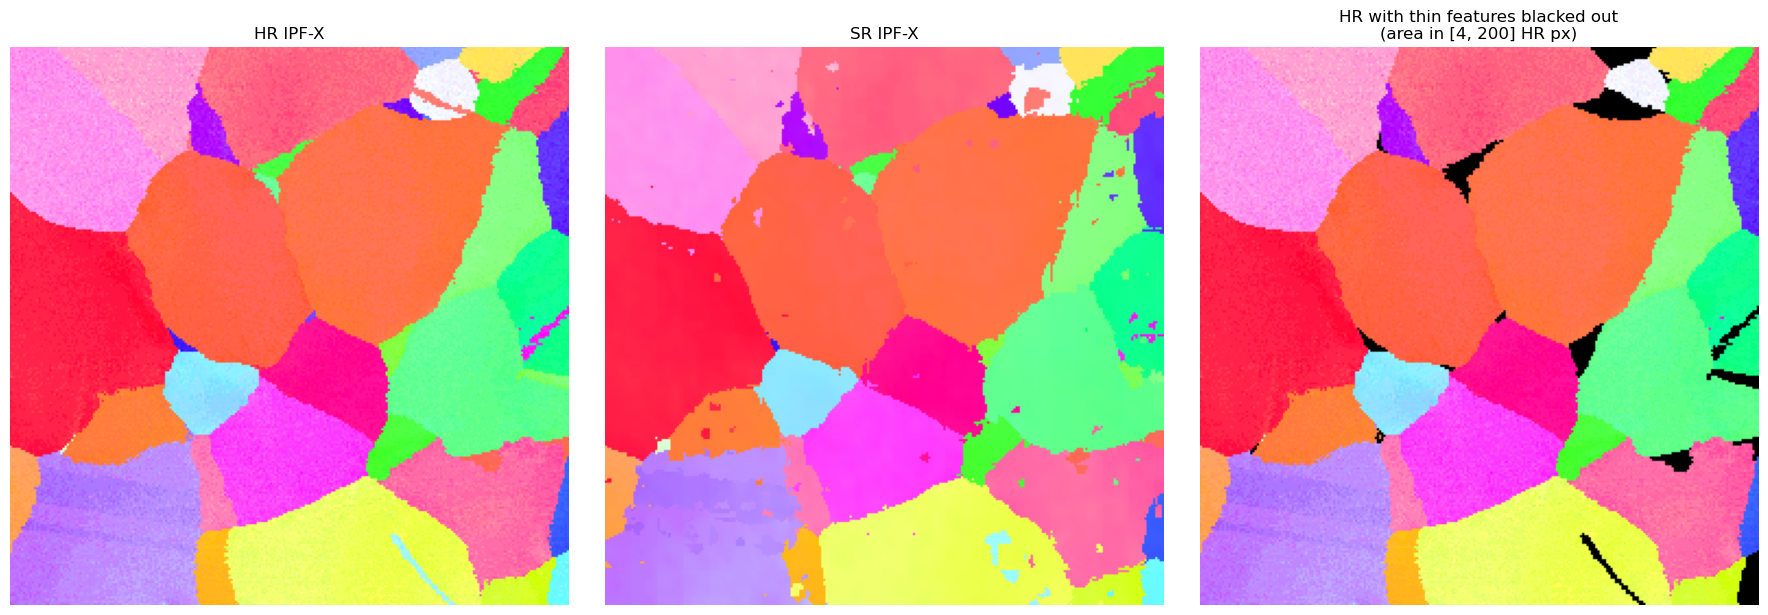

In [76]:
# Tunable: any HR component smaller than THIN_AREA HR pixels counts as a thin/twin feature.
# A 1-LR-pixel-wide twin spans ~ UPS_H HR pixels in width, and N_LR LR pixels long -> ~UPS_H * UPS_W * N_LR HR pixels.
# A 4-LR-pixel-long thin twin -> ~ 4 * 16 = 64 HR pixels. We use 200 as a generous upper bound.
THIN_AREA = 200
MIN_AREA  = 4        # ignore obvious noise singletons
thin_label_set = {int(l) for l, c in zip(uniq_lbl, uniq_cnt) if MIN_AREA <= c <= THIN_AREA}
thin_mask = np.isin(hr_labels, list(thin_label_set))
print(f'#thin components: {len(thin_label_set)}    #thin HR pixels: {int(thin_mask.sum())} '
      f'({100*thin_mask.mean():.2f} % of HR area)')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(ipf_x(hr_hwc)); axes[0].set_title('HR IPF-X'); axes[0].axis('off')
axes[1].imshow(ipf_x(sr_hwc)); axes[1].set_title('SR IPF-X'); axes[1].axis('off')
overlay = ipf_x(hr_hwc).copy()
overlay[thin_mask] = [0.0, 0.0, 0.0]
axes[2].imshow(overlay)
axes[2].set_title(f'HR with thin features blacked out\n(area in [{MIN_AREA}, {THIN_AREA}] HR px)')
axes[2].axis('off')
plt.tight_layout(); plt.show()

## 5 - Map every HR pixel to (macro tile, support-window node, patch token)
Indexing follows `OCRPPatchUpsampler._build_support_banks` and `_assemble_macro_patch_tokens`. The HR patch shape is `(tile * upsample) = (3 * 4) = 12`. The 9x9 support is centered on the macro tile center in the (replicate-padded) LR grid.

In [77]:
yy, xx = np.meshgrid(np.arange(HR_H), np.arange(HR_W), indexing='ij')
tile_y = yy // PATCH_H
tile_x = xx // PATCH_W
within_y = yy %  PATCH_H
within_x = xx %  PATCH_W
tile_idx_hw    = (tile_y * GRID_W + tile_x).astype(np.int64)        # tile index per HR pixel
patch_token_hw = (within_y * PATCH_W + within_x).astype(np.int64)   # token in [0, PATCH_H*PATCH_W)

lr_y = yy // UPS_H
lr_x = xx // UPS_W
tile_center_y = tile_y * TILE + (TILE // 2)
tile_center_x = tile_x * TILE + (TILE // 2)
center = WINDOW // 2
off_y = lr_y - tile_center_y + center
off_x = lr_x - tile_center_x + center
assert (off_y >= 0).all() and (off_y < WINDOW).all(), 'support y-offset out of window'
assert (off_x >= 0).all() and (off_x < WINDOW).all(), 'support x-offset out of window'
window_node_hw = (off_y * WINDOW + off_x).astype(np.int64)

cluster_ids_np = aux['cluster_ids'].cpu().numpy().astype(np.int64)   # (N_TILES, 81)
owner_idx_np   = aux['owner_idx'].cpu().numpy().astype(np.int64)     # (N_TILES, T)
hr_cluster_id_hw = cluster_ids_np[tile_idx_hw, window_node_hw]
hr_owner_slot_hw = owner_idx_np[tile_idx_hw, patch_token_hw]
print('HR cluster-id map:', hr_cluster_id_hw.shape, '   HR owner-slot map:', hr_owner_slot_hw.shape)

HR cluster-id map: (256, 256)    HR owner-slot map: (256, 256)


## 6 - Reconstruct `slot_cluster_label` and the per-tile slot occupation
`OCRPPatchUpsampler.forward` does not export `slot_cluster_label` to `aux`, so we reconstruct it from `slot_mask` and `cluster_ids`.

In [78]:
slot_mask_t  = aux['slot_mask']                                      # (N_TILES, K, 81)
slot_valid_t = aux['slot_valid']                                     # (N_TILES, K)
cluster_ids_t = aux['cluster_ids']
K = slot_mask_t.shape[1]
SENTINEL = 99999
_cids_exp = cluster_ids_t.unsqueeze(1).expand(-1, K, -1)
_masked   = torch.where(slot_mask_t.bool(), _cids_exp, torch.full_like(_cids_exp, SENTINEL))
slot_cluster_label_t = _masked.min(dim=-1).values
slot_cluster_label_t[slot_cluster_label_t == SENTINEL] = -1
slot_cluster_label = slot_cluster_label_t.cpu().numpy()              # (N_TILES, K)

# Build (tile, cluster) -> slot map for fast lookup.
tile_cluster_slot = {}
for t in range(N_TILES):
    for k in range(K):
        cid = int(slot_cluster_label[t, k])
        if cid >= 0:
            tile_cluster_slot[(t, cid)] = k
print(f'#unique (tile, cluster) entries packed into slots: {len(tile_cluster_slot)}')
print(f'avg surviving slots per tile: {(slot_cluster_label >= 0).sum(axis=1).mean():.2f} of K={K}')

#unique (tile, cluster) entries packed into slots: 1552
avg surviving slots per tile: 3.21 of K=6


## 7 - Per-thin-pixel attribution: did the cluster survive, was the routing correct?

In [79]:
thin_yy, thin_xx = np.where(thin_mask)
tile_idx_thin    = tile_idx_hw[thin_yy, thin_xx]
patch_token_thin = patch_token_hw[thin_yy, thin_xx]
cluster_id_thin  = hr_cluster_id_hw[thin_yy, thin_xx]
owner_slot_thin  = hr_owner_slot_hw[thin_yy, thin_xx]
twin_slot_thin   = np.full_like(tile_idx_thin, -1)
for i, (t, c) in enumerate(zip(tile_idx_thin, cluster_id_thin)):
    twin_slot_thin[i] = tile_cluster_slot.get((int(t), int(c)), -1)
cluster_survived = twin_slot_thin >= 0
routed_correctly = cluster_survived & (twin_slot_thin == owner_slot_thin)

router_target_slot_np = None
router_target_valid_np = None
router_target_slot_thin = np.full_like(tile_idx_thin, -1)
router_target_valid_thin = np.zeros(tile_idx_thin.shape, dtype=bool)
if 'router_target_slot' in aux and 'router_target_valid' in aux:
    router_target_slot_np = aux['router_target_slot'].cpu().numpy().astype(np.int64)
    router_target_valid_np = aux['router_target_valid'].cpu().numpy().astype(bool)
    router_target_slot_thin = router_target_slot_np[tile_idx_thin, patch_token_thin]
    router_target_valid_thin = router_target_valid_np[tile_idx_thin, patch_token_thin]

df_thin = pd.DataFrame({
    'y': thin_yy, 'x': thin_xx,
    'tile': tile_idx_thin, 'patch_token': patch_token_thin,
    'cluster': cluster_id_thin,
    'twin_slot': twin_slot_thin, 'owner_slot': owner_slot_thin,
    'cluster_survived': cluster_survived,
    'routed_correctly': routed_correctly,
    'router_target_slot': router_target_slot_thin,
    'router_target_valid': router_target_valid_thin,
})
n_thin = len(df_thin)
if n_thin == 0:
    print('No thin HR pixels detected at this THIN_AREA threshold.')
else:
    print(f'thin HR pixels                           : {n_thin}')
    print(f'  cluster survived top-K cut             : {int(cluster_survived.sum()):>6d}  ({100*cluster_survived.mean():.2f} %)')
    print(f'  cluster DROPPED (architectural failure): {int((~cluster_survived).sum()):>6d}  ({100*(~cluster_survived).mean():.2f} %)')
    print(f'  routed to correct slot (correct  end)  : {int(routed_correctly.sum()):>6d}  ({100*routed_correctly.mean():.2f} %)')
    survived_misrouted = cluster_survived & ~routed_correctly
    print(f'  survived but misrouted by router       : {int(survived_misrouted.sum()):>6d}  ({100*survived_misrouted.mean():.2f} %)')
    if router_target_slot_np is not None:
        lookup_agree = cluster_survived & router_target_valid_thin
        if lookup_agree.any():
            agree_rate = (router_target_slot_thin[lookup_agree] == twin_slot_thin[lookup_agree]).mean()
            print(f'  router target matches cluster-slot map : {100*agree_rate:>6.2f} %  (sanity check)')
        print(f'  thin pixels with deterministic target  : {int(router_target_valid_thin.sum()):>6d}  ({100*router_target_valid_thin.mean():.2f} %)')


thin HR pixels                           : 1665
  cluster survived top-K cut             :   1650  (99.10 %)
  cluster DROPPED (architectural failure):     15  (0.90 %)
  routed to correct slot (correct  end)  :   1018  (61.14 %)
  survived but misrouted by router       :    632  (37.96 %)
  router target matches cluster-slot map : 100.00 %  (sanity check)
  thin pixels with deterministic target  :   1650  (99.10 %)


## 8 - Failure-mode map
Each thin HR pixel is colored by where it failed: `dropped` (cluster never made the top-K), `misrouted` (cluster survived but the router argmax went to a different slot), or `correct`.

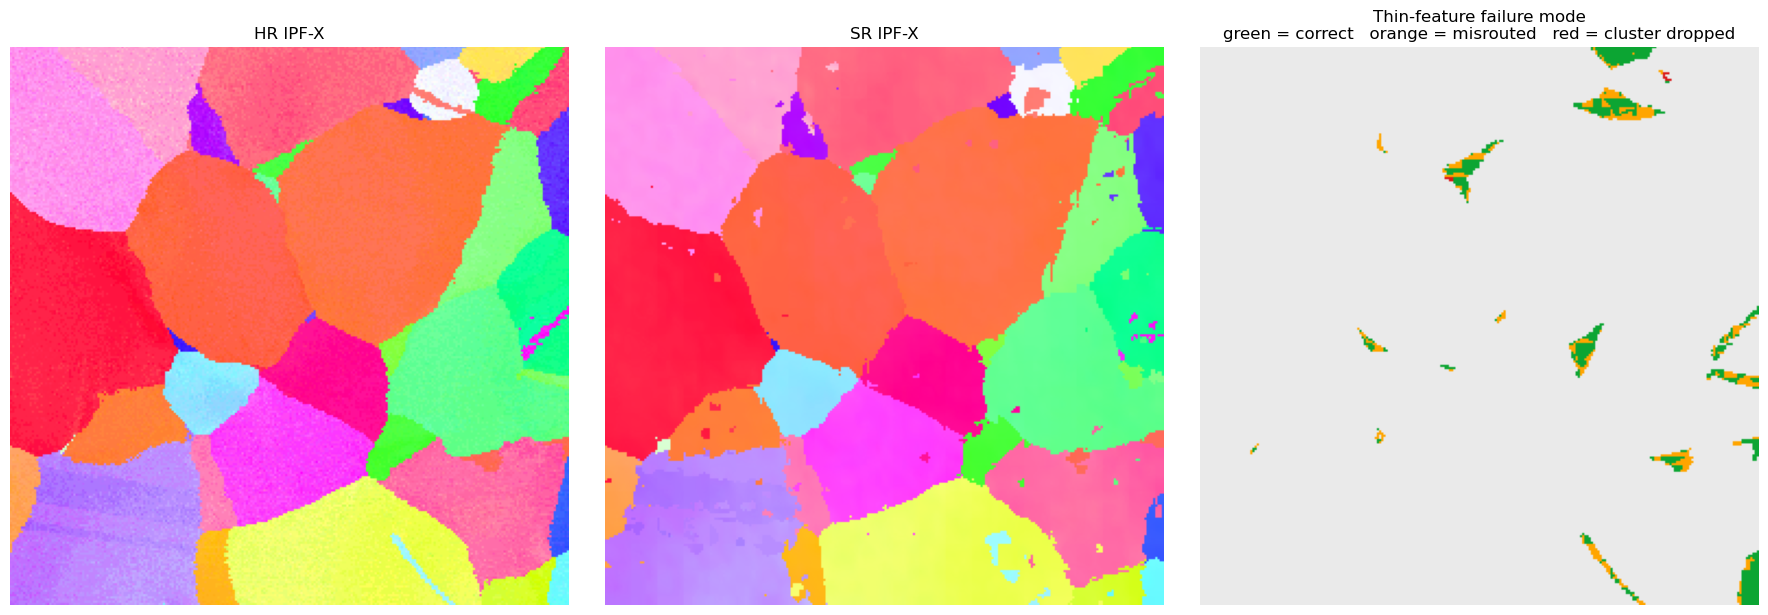

In [80]:
fail_code = np.zeros_like(thin_mask, dtype=np.int32)
for y, x, surv, ok in zip(thin_yy, thin_xx, cluster_survived, routed_correctly):
    fail_code[y, x] = 1 if ok else (2 if surv else 3)
palette = np.array([
    [0.92, 0.92, 0.92],   # 0: not thin (background)
    [0.05, 0.65, 0.20],   # 1: correct
    [1.00, 0.65, 0.00],   # 2: misrouted (cluster survived, router picked wrong slot)
    [0.85, 0.10, 0.10],   # 3: cluster dropped at slot-builder
])
fail_rgb = palette[fail_code]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(ipf_x(hr_hwc)); axes[0].set_title('HR IPF-X'); axes[0].axis('off')
axes[1].imshow(ipf_x(sr_hwc)); axes[1].set_title('SR IPF-X'); axes[1].axis('off')
axes[2].imshow(fail_rgb)
axes[2].set_title('Thin-feature failure mode\ngreen = correct   orange = misrouted   red = cluster dropped')
axes[2].axis('off')
plt.tight_layout(); plt.show()

## 9 - Distributions: clusters per tile, cluster mass, dropped-cluster mass
These plots quantify **top-K pressure**, but they do not by themselves prove that top-K pressure is the dominant cause of thin-twin failure.

1. **Distinct clusters per macro tile.** Tiles to the right of the red `kmax_slots` line are the ones that *must* drop something.
2. **Mass distribution of all clusters** (any tile). This shows how much low-mass structure is present in the support windows.
3. **Mass distribution of clusters that were actually dropped.** This is the right plot if the slot allocator is the main bottleneck.

Interpretation rule:
- If tiles with `#clusters > kmax_slots` are rare and dropped clusters are a small tail, then the allocator is a contributor, not the main failure mode.


Tiles with #clusters > kmax_slots (6): 25 of 484 (5.2 %)
all clusters: 1597,  dropped clusters: 45  (2.82 %)


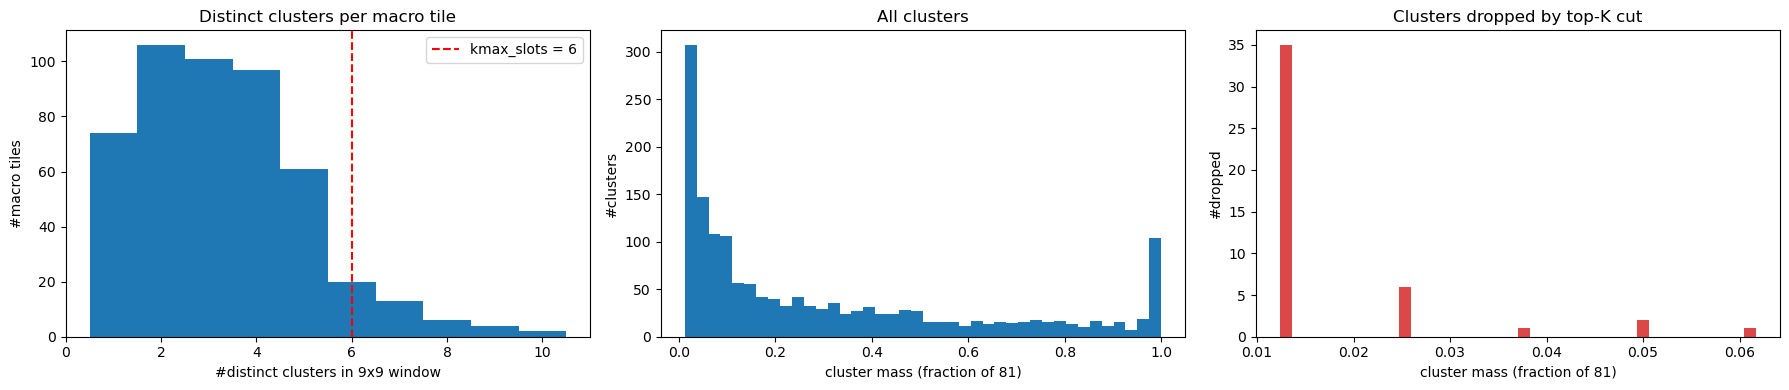

In [81]:
n_clusters_per_tile = np.array([len(np.unique(cluster_ids_np[t])) for t in range(N_TILES)])
tiles_dropping = (n_clusters_per_tile > K_MAX).sum()
print(f'Tiles with #clusters > kmax_slots ({K_MAX}): {tiles_dropping} of {N_TILES} '
      f'({100*tiles_dropping/N_TILES:.1f} %)')

all_masses, dropped_masses = [], []
for t in range(N_TILES):
    cids, cnts = np.unique(cluster_ids_np[t], return_counts=True)
    survived_set = set(int(c) for c in slot_cluster_label[t] if c >= 0)
    for cid, cnt in zip(cids, cnts):
        all_masses.append(cnt)
        if int(cid) not in survived_set:
            dropped_masses.append(cnt)
all_masses     = np.array(all_masses) / float(WINDOW * WINDOW)
dropped_masses = np.array(dropped_masses) / float(WINDOW * WINDOW) if dropped_masses else np.array([])
print(f'all clusters: {len(all_masses)},  dropped clusters: {len(dropped_masses)}  '
      f'({100*len(dropped_masses)/max(1,len(all_masses)):.2f} %)')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(n_clusters_per_tile, bins=np.arange(1, n_clusters_per_tile.max() + 2) - 0.5)
axes[0].axvline(K_MAX, color='r', ls='--', label=f'kmax_slots = {K_MAX}')
axes[0].set_xlabel('#distinct clusters in 9x9 window')
axes[0].set_ylabel('#macro tiles'); axes[0].legend()
axes[0].set_title('Distinct clusters per macro tile')
axes[1].hist(all_masses, bins=40)
axes[1].set_xlabel('cluster mass (fraction of 81)')
axes[1].set_ylabel('#clusters'); axes[1].set_title('All clusters')
if len(dropped_masses) > 0:
    axes[2].hist(dropped_masses, bins=40, color='tab:red', alpha=0.85)
axes[2].set_xlabel('cluster mass (fraction of 81)')
axes[2].set_ylabel('#dropped'); axes[2].set_title('Clusters dropped by top-K cut')
plt.tight_layout(); plt.show()

## 10 - Drill into a failure tile
Pick a tile that is genuinely bad on thin-feature routing. Prefer a tile where the thin-feature cluster **survived** but the router still failed, because that isolates the router rather than the slot allocator.


In [82]:
if n_thin > 0:
    per_tile = df_thin.groupby('tile').agg(
        n_thin_pixels=('y', 'size'),
        cluster_survived_frac=('cluster_survived', 'mean'),
        routed_correct_frac=('routed_correctly', 'mean'),
        router_target_valid_frac=('router_target_valid', 'mean'),
    ).reset_index()
    print('Per-tile thin-feature ledger (worst first):')
    print(per_tile.sort_values(['routed_correct_frac', 'cluster_survived_frac', 'n_thin_pixels'],
                               ascending=[True, True, False]).head(10).to_string(index=False))

    pure_router_fail = per_tile[per_tile['cluster_survived_frac'] >= 0.999]
    if len(pure_router_fail) > 0:
        target_tile = int(
            pure_router_fail.sort_values(['routed_correct_frac', 'n_thin_pixels'],
                                         ascending=[True, False]).iloc[0]['tile']
        )
        print('\nChoosing a tile where the thin-feature slot survived, so the failure is attributable to the router.')
    else:
        target_tile = int(
            per_tile.sort_values(['routed_correct_frac', 'cluster_survived_frac', 'n_thin_pixels'],
                                 ascending=[True, True, False]).iloc[0]['tile']
        )
        print('\nNo pure router-failure tile found first; using the overall worst tile.')
else:
    target_tile = 0
ty, tx = target_tile // GRID_W, target_tile % GRID_W
print(f'\nDrilling tile {target_tile}  (ty={ty}, tx={tx})')


Per-tile thin-feature ledger (worst first):
 tile  n_thin_pixels  cluster_survived_frac  routed_correct_frac  router_target_valid_frac
   72             14                   1.00             0.000000                      1.00
  432              9                   1.00             0.000000                      1.00
  329              3                   1.00             0.000000                      1.00
  331              2                   1.00             0.000000                      1.00
  315              1                   1.00             0.000000                      1.00
   37             33                   1.00             0.030303                      1.00
  314             10                   1.00             0.100000                      1.00
  433             34                   1.00             0.117647                      1.00
  231             14                   1.00             0.142857                      1.00
   39             12                   0.25   

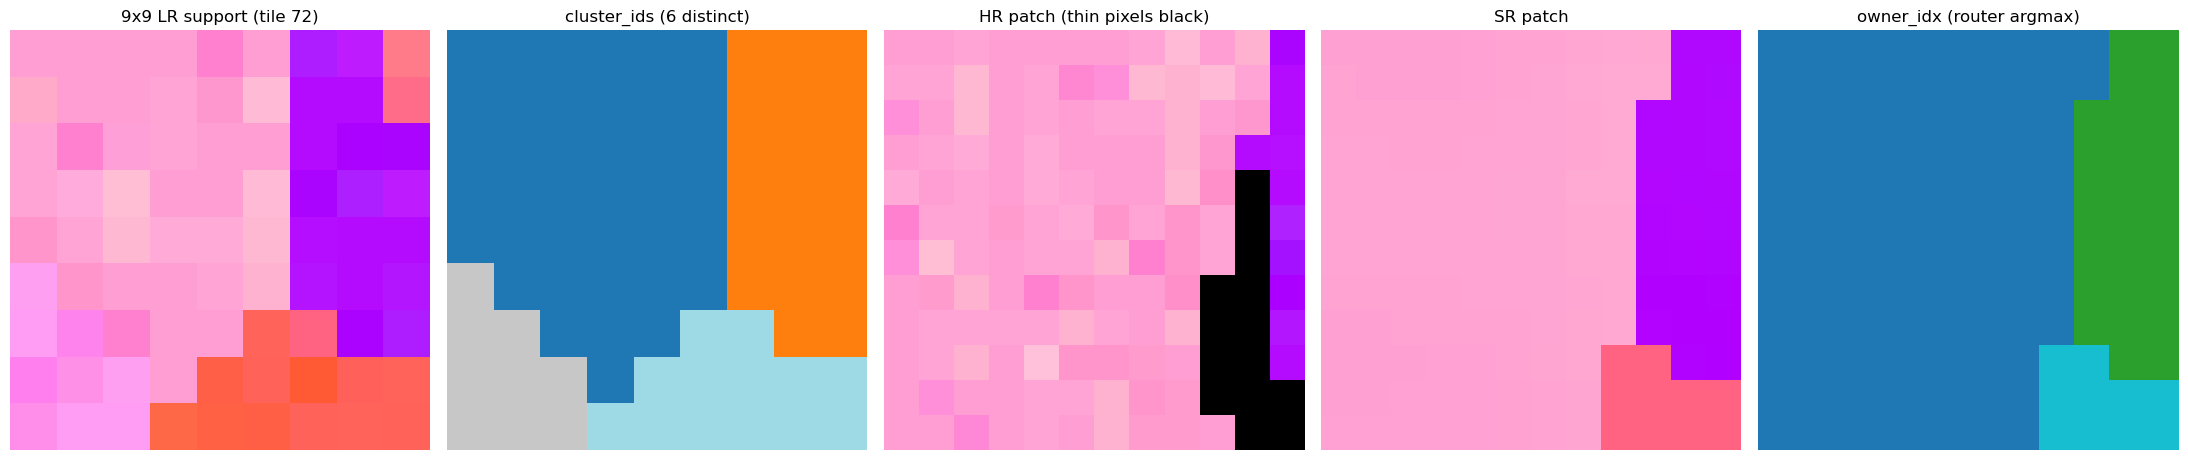

Slot occupation in this tile:
  slot 0: cluster   0  mass 39/81  HR-tokens routed 107/144
  slot 1: cluster   6  mass 18/81  HR-tokens routed 27/144
  slot 2: cluster  59  mass 12/81  HR-tokens routed 0/144
  slot 3: cluster  45  mass  9/81  HR-tokens routed 0/144
  slot 4: cluster   8  mass  2/81  HR-tokens routed 0/144
  slot 5: cluster  60  mass  1/81  HR-tokens routed 10/144
Dropped clusters (mass smallest first):


In [83]:
cluster_ids_2d = cluster_ids_np[target_tile].reshape(WINDOW, WINDOW)
bank_q_t = aux['bank_q'][target_tile].cpu()
bank_q_2d = bank_q_t.reshape(WINDOW, WINDOW, 4)

# What is the HR / SR patch for this tile? Crop with HR_H, HR_W bounds.
y0, y1 = ty * PATCH_H, min((ty + 1) * PATCH_H, HR_H)
x0, x1 = tx * PATCH_W, min((tx + 1) * PATCH_W, HR_W)
hr_patch = hr_hwc[y0:y1, x0:x1]
sr_patch = sr_hwc[y0:y1, x0:x1]
thin_patch = thin_mask[y0:y1, x0:x1]
owner_patch = hr_owner_slot_hw[y0:y1, x0:x1]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
axes[0].imshow(ipf_x(bank_q_2d), interpolation='nearest')
axes[0].set_title(f'9x9 LR support (tile {target_tile})'); axes[0].axis('off')
im_c = axes[1].imshow(cluster_ids_2d, cmap='tab20', interpolation='nearest')
axes[1].set_title(f'cluster_ids ({len(np.unique(cluster_ids_2d))} distinct)'); axes[1].axis('off')
axes[2].imshow(ipf_x(hr_patch), interpolation='nearest')
ovl = ipf_x(hr_patch).copy(); ovl[thin_patch] = 0.0
axes[2].imshow(ovl); axes[2].set_title('HR patch (thin pixels black)'); axes[2].axis('off')
axes[3].imshow(ipf_x(sr_patch), interpolation='nearest')
axes[3].set_title('SR patch'); axes[3].axis('off')
axes[4].imshow(owner_patch, cmap='tab10', vmin=0, vmax=K_MAX - 1, interpolation='nearest')
axes[4].set_title('owner_idx (router argmax)'); axes[4].axis('off')
plt.tight_layout(); plt.show()

# Slot ledger for the chosen tile
lines = ['Slot occupation in this tile:']
survived_set = set()
for k in range(K_MAX):
    cid = int(slot_cluster_label[target_tile, k])
    if cid < 0:
        lines.append(f'  slot {k}: <invalid>')
    else:
        survived_set.add(cid)
        mass = int((cluster_ids_2d == cid).sum())
        used = int((owner_patch == k).sum())
        lines.append(f'  slot {k}: cluster {cid:3d}  mass {mass:>2d}/81  HR-tokens routed {used}/{owner_patch.size}')
lines.append('Dropped clusters (mass smallest first):')
drop_rows = []
for cid in np.unique(cluster_ids_2d):
    if int(cid) not in survived_set:
        drop_rows.append((int((cluster_ids_2d == cid).sum()), int(cid)))
for mass, cid in sorted(drop_rows):
    lines.append(f'  cluster {cid:3d}  mass {mass:>2d}/81  -> SILENTLY DROPPED')
print('\n'.join(lines))

## 11 - Important config caveat: this checkpoint does not directly feed raw mass to the router
Claude's revised analysis was directionally right about the **router** being the bottleneck, but one detail needs correction for this specific checkpoint.

The config sets:
- `ocrp_router_slot_mass_power = 0.0`
- `ocrp_router_uniform_slot_mix = 1.0`

Inside `PatchSlotRouter._router_weight_context`, that means the router-side mass channel is flattened to the same value for every valid slot. So if we see low-rank slots being starved, the strongest culprit is not raw mass itself; it is the lack of a per-token geometric teacher plus any information leakage from slot rank / slot type.


In [84]:
router_slot_mass_power = float(getattr(cfg, 'ocrp_router_slot_mass_power', np.nan))
router_uniform_slot_mix = float(getattr(cfg, 'ocrp_router_uniform_slot_mix', np.nan))
mass_idx = model.ocrp.slot_builder.META_MASS
slot_type_start = model.ocrp.slot_builder.META_SLOT_TYPE_START
slot_type_end = slot_type_start + model.ocrp.slot_builder.SLOT_TYPE_DIM

slot_valid_router_t, slot_meta_router_t, router_weights_t = model.ocrp.router._router_weight_context(
    aux['slot_meta'].unsqueeze(0)
)
raw_mass_valid = aux['slot_meta'][..., mass_idx].cpu().numpy()[aux['slot_valid'].cpu().numpy().astype(bool)]
router_mass_valid = (
    slot_meta_router_t.squeeze(0)[..., mass_idx].detach().cpu().numpy()
    [aux['slot_valid'].cpu().numpy().astype(bool)]
)
print('router_slot_mass_power :', router_slot_mass_power)
print('router_uniform_slot_mix:', router_uniform_slot_mix)
print('raw mass stats         :',
      f'min={raw_mass_valid.min():.4f}  max={raw_mass_valid.max():.4f}  unique≈{len(np.unique(np.round(raw_mass_valid, 4)))}')
print('router-side mass stats :',
      f'min={router_mass_valid.min():.4f}  max={router_mass_valid.max():.4f}  unique≈{len(np.unique(np.round(router_mass_valid, 4)))}')
print('unique router-side mass values on valid slots:',
      np.unique(np.round(router_mass_valid, 4))[:10])
print('\nConclusion: raw cluster mass varies, but the router-facing mass channel is effectively flattened in this checkpoint.')


router_slot_mass_power : 0.0
router_uniform_slot_mix: 1.0
raw mass stats         : min=0.0123  max=1.0000  unique≈81
router-side mass stats : min=1.0000  max=1.0000  unique≈1
unique router-side mass values on valid slots: [1.]

Conclusion: raw cluster mass varies, but the router-facing mass channel is effectively flattened in this checkpoint.


## 12 - Slot-rank starvation on this sample
`ClusterSlotBuilder` sorts surviving clusters into slot indices by rank. If the router is starving thin twins because they tend to live in lower-ranked surviving slots, we should see:

1. Thin-feature correctness falling with slot index.
2. Higher slot indices being valid fairly often, but still receiving zero routed HR tokens in many tiles.

That pattern would pinpoint the issue much more narrowly than “the router is bad”: it would say the router is under-using low-rank surviving slots.


 slot_rank  valid_tiles  zero_token_valid_tiles  zero_token_valid_rate  routed_tokens_total  mean_tokens_when_valid  thin_pixels_survived  thin_pixels_correct  thin_correct_rate
         0          484                       0               0.000000                59262              122.442149                   627                  367           0.585327
         1          410                     163               0.397561                 7891               19.246341                   397                  263           0.662469
         2          304                     215               0.707237                 1750                5.756579                   341                  207           0.607038
         3          203                     176               0.866995                  501                2.467980                   203                  136           0.669951
         4          106                      90               0.849057                  184                1.7

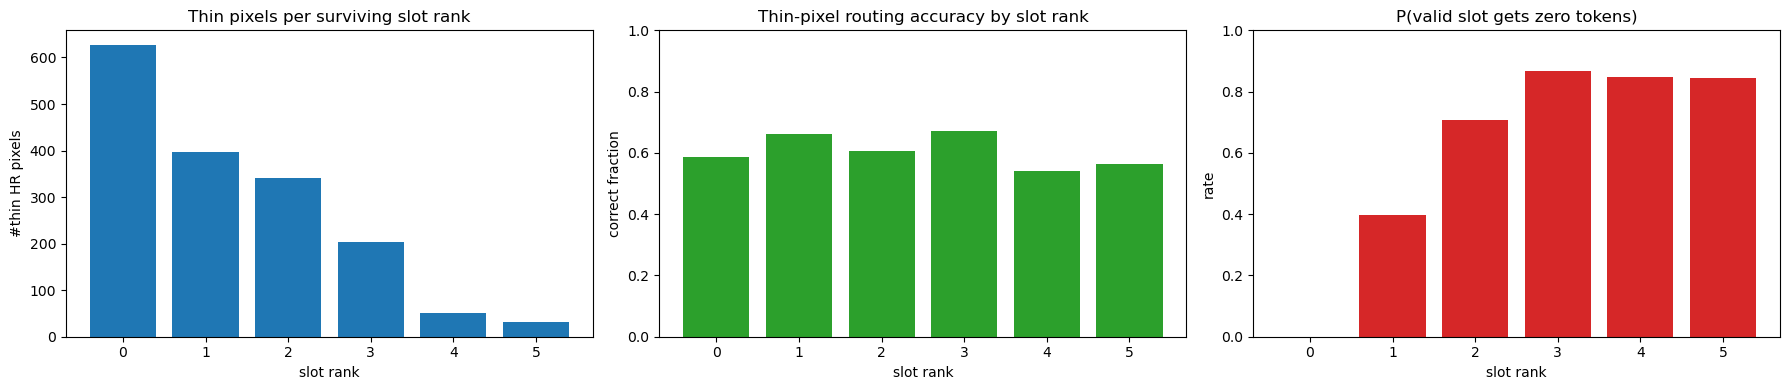


If the rightmost bars are high in the last panel and low in the middle panel, that is direct evidence of low-rank slot starvation.


In [85]:
owner_counts_tile = np.stack(
    [np.bincount(owner_idx_np[t], minlength=K_MAX) for t in range(N_TILES)],
    axis=0,
)
valid_slot_mask = slot_cluster_label >= 0
valid_tiles_by_slot = valid_slot_mask.sum(axis=0)
zero_token_valid_tiles_by_slot = ((owner_counts_tile == 0) & valid_slot_mask).sum(axis=0)
routed_tokens_by_slot = owner_counts_tile.sum(axis=0)
mean_tokens_when_valid = routed_tokens_by_slot / np.maximum(valid_tiles_by_slot, 1)
zero_token_valid_rate = zero_token_valid_tiles_by_slot / np.maximum(valid_tiles_by_slot, 1)

thin_total_by_slot = np.array([(df_thin['twin_slot'] == k).sum() for k in range(K_MAX)], dtype=np.int64)
thin_correct_by_slot = np.array(
    [((df_thin['twin_slot'] == k) & df_thin['routed_correctly']).sum() for k in range(K_MAX)],
    dtype=np.int64,
)
thin_correct_rate_by_slot = thin_correct_by_slot / np.maximum(thin_total_by_slot, 1)

slot_rank_table = pd.DataFrame({
    'slot_rank': np.arange(K_MAX),
    'valid_tiles': valid_tiles_by_slot,
    'zero_token_valid_tiles': zero_token_valid_tiles_by_slot,
    'zero_token_valid_rate': zero_token_valid_rate,
    'routed_tokens_total': routed_tokens_by_slot,
    'mean_tokens_when_valid': mean_tokens_when_valid,
    'thin_pixels_survived': thin_total_by_slot,
    'thin_pixels_correct': thin_correct_by_slot,
    'thin_correct_rate': thin_correct_rate_by_slot,
})
print(slot_rank_table.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(np.arange(K_MAX), thin_total_by_slot, color='tab:blue')
axes[0].set_title('Thin pixels per surviving slot rank')
axes[0].set_xlabel('slot rank'); axes[0].set_ylabel('#thin HR pixels')
axes[1].bar(np.arange(K_MAX), thin_correct_rate_by_slot, color='tab:green')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Thin-pixel routing accuracy by slot rank')
axes[1].set_xlabel('slot rank'); axes[1].set_ylabel('correct fraction')
axes[2].bar(np.arange(K_MAX), zero_token_valid_rate, color='tab:red')
axes[2].set_ylim(0.0, 1.0)
axes[2].set_title('P(valid slot gets zero tokens)')
axes[2].set_xlabel('slot rank'); axes[2].set_ylabel('rate')
plt.tight_layout(); plt.show()

print('\nIf the rightmost bars are high in the last panel and low in the middle panel, that is direct evidence of low-rank slot starvation.')


## 13 - Aggregate across multiple validation samples
Single-sample numbers can be noisy. We sweep `N_AGG` val samples, accumulate the same per-thin-pixel attribution, and print a corpus-level breakdown.

In addition to the previous totals, we now also accumulate:
- how often each slot rank is valid,
- how often each valid slot rank receives **zero** routed HR tokens,
- how well the router matches the deterministic geometry target implied by the surviving slots.


In [86]:
def per_sample_attribution(model, lr_hwc_q, hr_hwc_q):
    """Return per-thin-pixel records and slot-level summaries for one sample."""
    lr_dev = lr_hwc_q.permute(2, 0, 1).to(DEVICE, dtype=torch.float32)
    lr_flat_l, lr_shape_l = _flatten_quat_chw(lr_dev)
    with torch.no_grad():
        feat_lr_l = model.encode(lr_flat_l)
        _, hr_shape_l, aux_l = model._forward_sr_features(
            lr_quats=lr_flat_l, feat_lr=feat_lr_l, lr_shape=lr_shape_l, return_aux=True,
        )
    aux_l = {k: _unbatch(v) for k, v in aux_l.items()}
    gh, gw = (int(v) for v in aux_l['support_grid_shape'])
    Hh, Wh = (int(v) for v in hr_shape_l)
    cids = aux_l['cluster_ids'].cpu().numpy().astype(np.int64)
    own  = aux_l['owner_idx'].cpu().numpy().astype(np.int64)
    sm   = aux_l['slot_mask']
    Kk   = sm.shape[1]
    cids_t = aux_l['cluster_ids']
    SENT = 99999
    masked = torch.where(sm.bool(),
                         cids_t.unsqueeze(1).expand(-1, Kk, -1),
                         torch.full_like(cids_t.unsqueeze(1).expand(-1, Kk, -1), SENT))
    scl = masked.min(dim=-1).values
    scl[scl == SENT] = -1
    scl_np = scl.cpu().numpy()
    tcs = {}
    for t in range(gh * gw):
        for k in range(Kk):
            cid = int(scl_np[t, k])
            if cid >= 0:
                tcs[(t, cid)] = k
    yy_, xx_ = np.meshgrid(np.arange(Hh), np.arange(Wh), indexing='ij')
    ti = ((yy_ // PATCH_H) * gw + (xx_ // PATCH_W)).astype(np.int64)
    pt = ((yy_ %  PATCH_H) * PATCH_W + (xx_ %  PATCH_W)).astype(np.int64)
    lr_y_ = yy_ // UPS_H; lr_x_ = xx_ // UPS_W
    cy = (yy_ // PATCH_H) * TILE + TILE // 2
    cx = (xx_ // PATCH_W) * TILE + TILE // 2
    wn = ((lr_y_ - cy + WINDOW // 2) * WINDOW + (lr_x_ - cx + WINDOW // 2)).astype(np.int64)
    cluster_id_hw = cids[ti, wn]
    owner_hw      = own[ti, pt]
    hr_lab, _ = grid_components(hr_hwc_q, model.encoder.sym_ops, threshold_deg=2.0, connectivity=8)
    ulb, ucn = np.unique(hr_lab, return_counts=True)
    thin_set = {int(l) for l, c in zip(ulb, ucn) if MIN_AREA <= c <= THIN_AREA}
    tm = np.isin(hr_lab, list(thin_set))
    ys_, xs_ = np.where(tm)
    ts_ = ti[ys_, xs_]; cs_ = cluster_id_hw[ys_, xs_]; os_ = owner_hw[ys_, xs_]
    twin = np.array([tcs.get((int(tt), int(cc)), -1) for tt, cc in zip(ts_, cs_)], dtype=np.int64)
    surv = twin >= 0
    okrt = surv & (twin == os_)

    rts = aux_l.get('router_target_slot', None)
    rtv = aux_l.get('router_target_valid', None)
    if rts is not None and rtv is not None:
        rts_np = rts.cpu().numpy().astype(np.int64)
        rtv_np = rtv.cpu().numpy().astype(bool)
        router_target_valid_tokens = int(rtv_np.sum())
        router_target_correct_tokens = int((own[rtv_np] == rts_np[rtv_np]).sum())
    else:
        router_target_valid_tokens = 0
        router_target_correct_tokens = 0

    slot_token_counts_per_tile = np.stack(
        [np.bincount(own[t], minlength=Kk) for t in range(gh * gw)],
        axis=0,
    )
    valid_slots = scl_np >= 0
    valid_tiles_by_slot = valid_slots.sum(axis=0).astype(np.int64)
    zero_token_valid_tiles_by_slot = (
        ((slot_token_counts_per_tile == 0) & valid_slots).sum(axis=0).astype(np.int64)
    )
    routed_tokens_by_slot = slot_token_counts_per_tile.sum(axis=0).astype(np.int64)
    thin_total_by_slot = (
        np.bincount(twin[surv], minlength=Kk).astype(np.int64)
        if surv.any() else np.zeros(Kk, dtype=np.int64)
    )
    thin_correct_by_slot = (
        np.bincount(twin[okrt], minlength=Kk).astype(np.int64)
        if okrt.any() else np.zeros(Kk, dtype=np.int64)
    )

    n_clusters_l = np.array([len(np.unique(cids[t])) for t in range(gh * gw)])
    return dict(
        n_thin=len(ys_),
        n_survived=int(surv.sum()),
        n_correct=int(okrt.sum()),
        n_misrouted=int((surv & ~okrt).sum()),
        n_dropped=int((~surv).sum()),
        n_tiles=gh * gw,
        tiles_with_more_than_K=int((n_clusters_l > Kk).sum()),
        n_clusters_per_tile=n_clusters_l,
        thin_total_by_slot=thin_total_by_slot,
        thin_correct_by_slot=thin_correct_by_slot,
        valid_tiles_by_slot=valid_tiles_by_slot,
        zero_token_valid_tiles_by_slot=zero_token_valid_tiles_by_slot,
        routed_tokens_by_slot=routed_tokens_by_slot,
        router_target_valid_tokens=router_target_valid_tokens,
        router_target_correct_tokens=router_target_correct_tokens,
    )


In [87]:
N_AGG = 8
loader_agg = build_dataloader(
    dataset_root=cfg.dataset_root, split=SPLIT, batch_size=1, shuffle=False,
    num_workers=0, preload=False, preload_torch=False, pin_memory=False,
    take_first=N_AGG, seed=int(getattr(cfg, 'seed', 42)),
)
agg_rows = []
all_n_clusters = []
agg_array_lists = {
    'thin_total_by_slot': [],
    'thin_correct_by_slot': [],
    'valid_tiles_by_slot': [],
    'zero_token_valid_tiles_by_slot': [],
    'routed_tokens_by_slot': [],
}
router_target_valid_total = 0
router_target_correct_total = 0
for i, batch_i in enumerate(loader_agg):
    if i >= N_AGG: break
    lr_i, hr_i, _ = _unpack_batch(batch_i)
    lr_i_hwc = _to_hwc_quat_single(lr_i[0]).detach().cpu()
    hr_i_hwc = _to_hwc_quat_single(hr_i[0]).detach().cpu()
    rec = per_sample_attribution(model, lr_i_hwc, hr_i_hwc)
    rec['sample'] = i
    all_n_clusters.append(rec.pop('n_clusters_per_tile'))
    for key in agg_array_lists:
        agg_array_lists[key].append(rec.pop(key))
    router_target_valid_total += rec.pop('router_target_valid_tokens')
    router_target_correct_total += rec.pop('router_target_correct_tokens')
    agg_rows.append(rec)
    print(f'sample {i}: thin={rec["n_thin"]:>5d}  '
          f'dropped={rec["n_dropped"]:>5d} ({100*rec["n_dropped"]/max(1,rec["n_thin"]):5.1f}%)  '
          f'misrouted={rec["n_misrouted"]:>4d}  correct={rec["n_correct"]:>5d}  '
          f'tiles>K={rec["tiles_with_more_than_K"]}/{rec["n_tiles"]}')
df_agg = pd.DataFrame(agg_rows)
agg_slot_totals = {
    key: (np.sum(np.stack(vals, axis=0), axis=0) if len(vals) > 0 else np.zeros(K_MAX, dtype=np.int64))
    for key, vals in agg_array_lists.items()
}
agg_router_target_acc = router_target_correct_total / max(1, router_target_valid_total)
tot = df_agg[['n_thin', 'n_dropped', 'n_misrouted', 'n_correct']].sum()
print('\nTotals across', N_AGG, 'val samples:')
print(tot.to_string())
if tot['n_thin'] > 0:
    print(f"\nFraction of thin pixels with cluster DROPPED      : {100*tot['n_dropped']/tot['n_thin']:.2f} %")
    print(f"Fraction of thin pixels misrouted (slot survived) : {100*tot['n_misrouted']/tot['n_thin']:.2f} %")
    print(f"Fraction of thin pixels correctly routed          : {100*tot['n_correct']/tot['n_thin']:.2f} %")
print(f"Aggregate all-token agreement with geometry target: {100*agg_router_target_acc:.2f} %")


sample 0: thin= 1665  dropped=   15 (  0.9%)  misrouted= 632  correct= 1018  tiles>K=25/484
sample 1: thin= 1605  dropped=   20 (  1.2%)  misrouted= 561  correct= 1024  tiles>K=20/484
sample 2: thin= 1359  dropped=    0 (  0.0%)  misrouted= 478  correct=  881  tiles>K=19/484
sample 3: thin= 2294  dropped=  129 (  5.6%)  misrouted= 865  correct= 1300  tiles>K=76/484
sample 4: thin= 1724  dropped=   58 (  3.4%)  misrouted= 663  correct= 1003  tiles>K=49/484
sample 5: thin= 1387  dropped=   53 (  3.8%)  misrouted= 487  correct=  847  tiles>K=30/484
sample 6: thin=  876  dropped=   18 (  2.1%)  misrouted= 313  correct=  545  tiles>K=21/484
sample 7: thin= 3007  dropped=   92 (  3.1%)  misrouted=1102  correct= 1813  tiles>K=56/484

Totals across 8 val samples:
n_thin         13917
n_dropped        385
n_misrouted     5101
n_correct       8431

Fraction of thin pixels with cluster DROPPED      : 2.77 %
Fraction of thin pixels misrouted (slot survived) : 36.65 %
Fraction of thin pixels correc

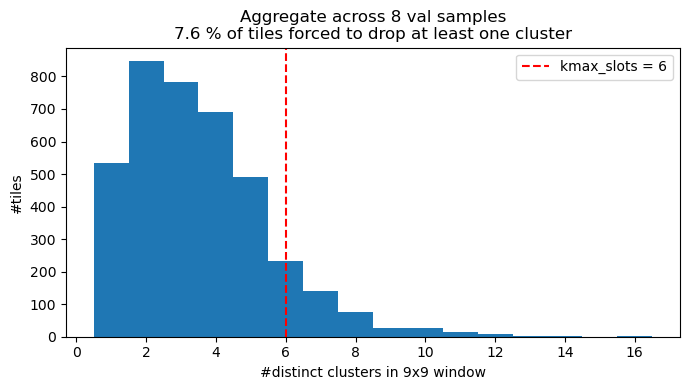

In [88]:
all_n_clusters_flat = np.concatenate(all_n_clusters) if all_n_clusters else np.array([])
if all_n_clusters_flat.size > 0:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    bins = np.arange(1, all_n_clusters_flat.max() + 2) - 0.5
    ax.hist(all_n_clusters_flat, bins=bins)
    ax.axvline(K_MAX, color='r', ls='--', label=f'kmax_slots = {K_MAX}')
    drop_frac = (all_n_clusters_flat > K_MAX).mean()
    ax.set_xlabel('#distinct clusters in 9x9 window')
    ax.set_ylabel('#tiles')
    ax.set_title(f'Aggregate across {N_AGG} val samples\n{100*drop_frac:.1f} % of tiles forced to drop at least one cluster')
    ax.legend(); plt.tight_layout(); plt.show()

## 14 - Aggregate slot-rank starvation across validation samples
The single-sample pattern is useful, but the more important question is whether it persists across the validation set.

This section aggregates slot-rank usage over the same `N_AGG` samples:
- how often each slot rank is valid,
- how often a valid slot rank receives zero routed tokens,
- how accurate thin-feature routing is when the thin feature survives into that slot rank.


 slot_rank  valid_tiles  zero_token_valid_tiles  zero_token_valid_rate  routed_tokens_total  mean_tokens_when_valid  thin_pixels_survived  thin_pixels_correct  thin_correct_rate
         0         3872                       1               0.000258               469432              121.237603                  4680                 2955           0.631410
         1         3338                    1247               0.373577                64955               19.459257                  2806                 1811           0.645403
         2         2492                    1732               0.695024                14945                5.997191                  2759                 1742           0.631388
         3         1710                    1431               0.836842                 4755                2.780702                  1828                 1065           0.582604
         4         1019                     869               0.852797                 2167                2.1

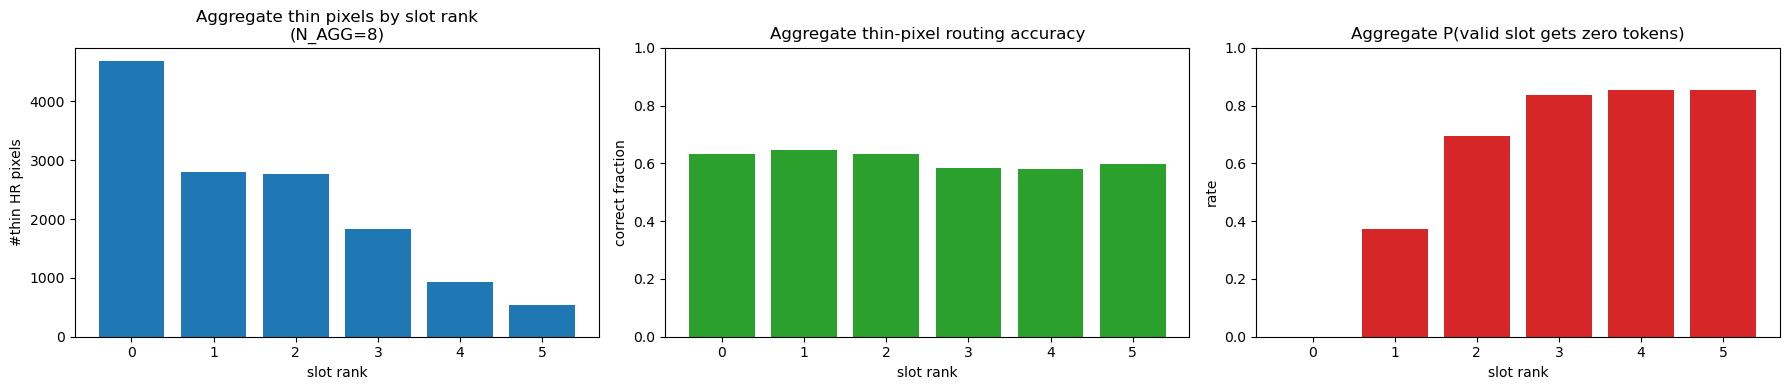

In [89]:
agg_valid_tiles_by_slot = agg_slot_totals['valid_tiles_by_slot']
agg_zero_token_valid_tiles_by_slot = agg_slot_totals['zero_token_valid_tiles_by_slot']
agg_routed_tokens_by_slot = agg_slot_totals['routed_tokens_by_slot']
agg_thin_total_by_slot = agg_slot_totals['thin_total_by_slot']
agg_thin_correct_by_slot = agg_slot_totals['thin_correct_by_slot']

agg_zero_token_valid_rate = agg_zero_token_valid_tiles_by_slot / np.maximum(agg_valid_tiles_by_slot, 1)
agg_mean_tokens_when_valid = agg_routed_tokens_by_slot / np.maximum(agg_valid_tiles_by_slot, 1)
agg_thin_correct_rate = agg_thin_correct_by_slot / np.maximum(agg_thin_total_by_slot, 1)

agg_slot_rank_table = pd.DataFrame({
    'slot_rank': np.arange(K_MAX),
    'valid_tiles': agg_valid_tiles_by_slot,
    'zero_token_valid_tiles': agg_zero_token_valid_tiles_by_slot,
    'zero_token_valid_rate': agg_zero_token_valid_rate,
    'routed_tokens_total': agg_routed_tokens_by_slot,
    'mean_tokens_when_valid': agg_mean_tokens_when_valid,
    'thin_pixels_survived': agg_thin_total_by_slot,
    'thin_pixels_correct': agg_thin_correct_by_slot,
    'thin_correct_rate': agg_thin_correct_rate,
})
print(agg_slot_rank_table.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(np.arange(K_MAX), agg_thin_total_by_slot, color='tab:blue')
axes[0].set_title(f'Aggregate thin pixels by slot rank\n(N_AGG={N_AGG})')
axes[0].set_xlabel('slot rank'); axes[0].set_ylabel('#thin HR pixels')
axes[1].bar(np.arange(K_MAX), agg_thin_correct_rate, color='tab:green')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Aggregate thin-pixel routing accuracy')
axes[1].set_xlabel('slot rank'); axes[1].set_ylabel('correct fraction')
axes[2].bar(np.arange(K_MAX), agg_zero_token_valid_rate, color='tab:red')
axes[2].set_ylim(0.0, 1.0)
axes[2].set_title('Aggregate P(valid slot gets zero tokens)')
axes[2].set_xlabel('slot rank'); axes[2].set_ylabel('rate')
plt.tight_layout(); plt.show()


## 15 - Geometry-target agreement and an inference-time bias sweep
Once the slot allocator has survived clusters, there is a deterministic geometric ownership target available:

- each HR token sits over a specific LR support node,
- that support node belongs to one surviving slot or none,
- so the router could, in principle, be trained toward that slot directly.

This section asks two questions:
1. How well does the current router already match that target?
2. If we add a small positive bias to the target slot's logit **without retraining**, does routing improve immediately?

If the answer to (2) is yes, that is strong evidence that the model's bottleneck is missing router supervision / prior, not missing representational capacity.


Current sample: all-token agreement with geometry target  = 90.62 %
Current sample: thin-pixel agreement with geometry target = 61.70 %
 bias  overall_valid_token_acc  thin_valid_fraction  thin_valid_token_acc  thin_correct_fraction_of_all_thin
 0.00                 0.906243             0.990991              0.616970                           0.611411
 0.25                 0.950968             0.990991              0.806061                           0.798799
 0.50                 0.973323             0.990991              0.915758                           0.907508
 1.00                 0.992433             0.990991              0.975758                           0.966967


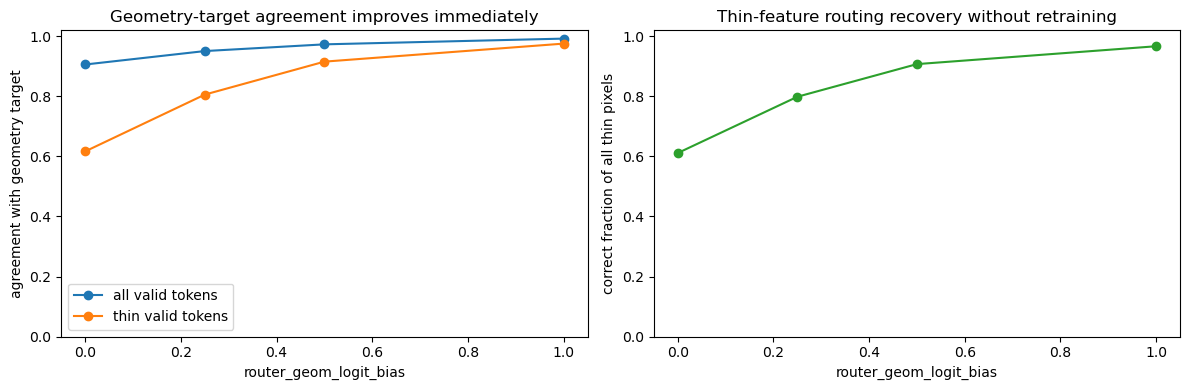

In [90]:
if router_target_slot_np is None or router_target_valid_np is None:
    raise RuntimeError('This notebook expects router_target_slot/router_target_valid in aux. Re-run with the updated model code.')

overall_router_target_acc = (
    (owner_idx_np[router_target_valid_np] == router_target_slot_np[router_target_valid_np]).mean()
    if router_target_valid_np.any() else np.nan
)
thin_router_target_valid = router_target_valid_np[tile_idx_thin, patch_token_thin]
thin_router_target_acc = (
    (owner_slot_thin[thin_router_target_valid] == router_target_slot_thin[thin_router_target_valid]).mean()
    if thin_router_target_valid.any() else np.nan
)
print(f'Current sample: all-token agreement with geometry target  = {100*overall_router_target_acc:.2f} %')
print(f'Current sample: thin-pixel agreement with geometry target = {100*thin_router_target_acc:.2f} %')

BIAS_SWEEP = [0.0, 0.25, 0.50, 1.00]
orig_bias = float(getattr(model.ocrp, 'router_geom_logit_bias', 0.0))
rows = []
try:
    for bias in BIAS_SWEEP:
        model.ocrp.router_geom_logit_bias = float(bias)
        with torch.no_grad():
            _, _, aux_b = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
        aux_b = {k: _unbatch(v) for k, v in aux_b.items()}
        owner_b = aux_b['owner_idx'].cpu().numpy().astype(np.int64)
        target_b = aux_b['router_target_slot'].cpu().numpy().astype(np.int64)
        valid_b = aux_b['router_target_valid'].cpu().numpy().astype(bool)
        overall_acc_b = (
            (owner_b[valid_b] == target_b[valid_b]).mean()
            if valid_b.any() else np.nan
        )
        thin_valid_b = valid_b[tile_idx_thin, patch_token_thin]
        thin_target_b = target_b[tile_idx_thin, patch_token_thin]
        thin_owner_b = owner_b[tile_idx_thin, patch_token_thin]
        thin_acc_valid_b = (
            (thin_owner_b[thin_valid_b] == thin_target_b[thin_valid_b]).mean()
            if thin_valid_b.any() else np.nan
        )
        thin_acc_all_b = (
            (thin_owner_b[thin_valid_b] == thin_target_b[thin_valid_b]).sum() / max(1, n_thin)
            if thin_valid_b.any() else 0.0
        )
        rows.append({
            'bias': bias,
            'overall_valid_token_acc': overall_acc_b,
            'thin_valid_fraction': thin_valid_b.mean() if len(thin_valid_b) > 0 else np.nan,
            'thin_valid_token_acc': thin_acc_valid_b,
            'thin_correct_fraction_of_all_thin': thin_acc_all_b,
        })
finally:
    model.ocrp.router_geom_logit_bias = orig_bias

df_bias = pd.DataFrame(rows)
print(df_bias.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_bias['bias'], df_bias['overall_valid_token_acc'], marker='o', label='all valid tokens')
axes[0].plot(df_bias['bias'], df_bias['thin_valid_token_acc'], marker='o', label='thin valid tokens')
axes[0].set_ylim(0.0, 1.02)
axes[0].set_xlabel('router_geom_logit_bias')
axes[0].set_ylabel('agreement with geometry target')
axes[0].set_title('Geometry-target agreement improves immediately')
axes[0].legend()
axes[1].plot(df_bias['bias'], df_bias['thin_correct_fraction_of_all_thin'], marker='o', color='tab:green')
axes[1].set_ylim(0.0, 1.02)
axes[1].set_xlabel('router_geom_logit_bias')
axes[1].set_ylabel('correct fraction of all thin pixels')
axes[1].set_title('Thin-feature routing recovery without retraining')
plt.tight_layout(); plt.show()


## 16 - Demonstrate the correction on the selected pure router-failure tile
The bias sweep above already showed something very important: a tiny positive bias toward the deterministic target slot dramatically improves thin-feature routing **without changing the slot allocator**.

This demo block is now **self-contained after the model/config setup cells**. It rebuilds the minimum sample state it needs from `cfg`, `model`, and the dataloader, so you can rerun this section without rerunning the full notebook.

This section visualizes the claim on a tile where the thin-feature slot survived but the router still failed. If the target slot map stays the same and only owner assignment changes, then the failure is squarely in router ownership.


Current sample: all-token agreement with geometry target  = 90.62 %
Current sample: thin-pixel agreement with geometry target = 61.70 %
 bias  overall_valid_token_acc  thin_valid_fraction  thin_valid_token_acc  thin_correct_fraction_of_all_thin
 0.00                 0.906243             0.990991              0.616970                           0.611411
 0.25                 0.950968             0.990991              0.806061                           0.798799
 0.50                 0.973323             0.990991              0.915758                           0.907508
 1.00                 0.992433             0.990991              0.975758                           0.966967


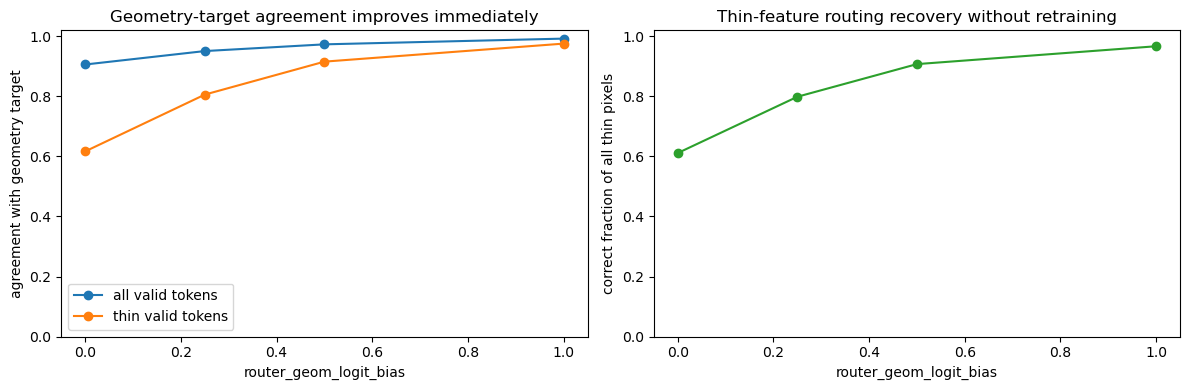


Tile 72: geometry bias demo at bias = 0.50
  valid-token agreement: 107/144 (74.3 %)  ->  141/144 (97.9 %)
  thin-pixel agreement : 0/14 (0.0 %)  ->  13/14 (92.9 %)


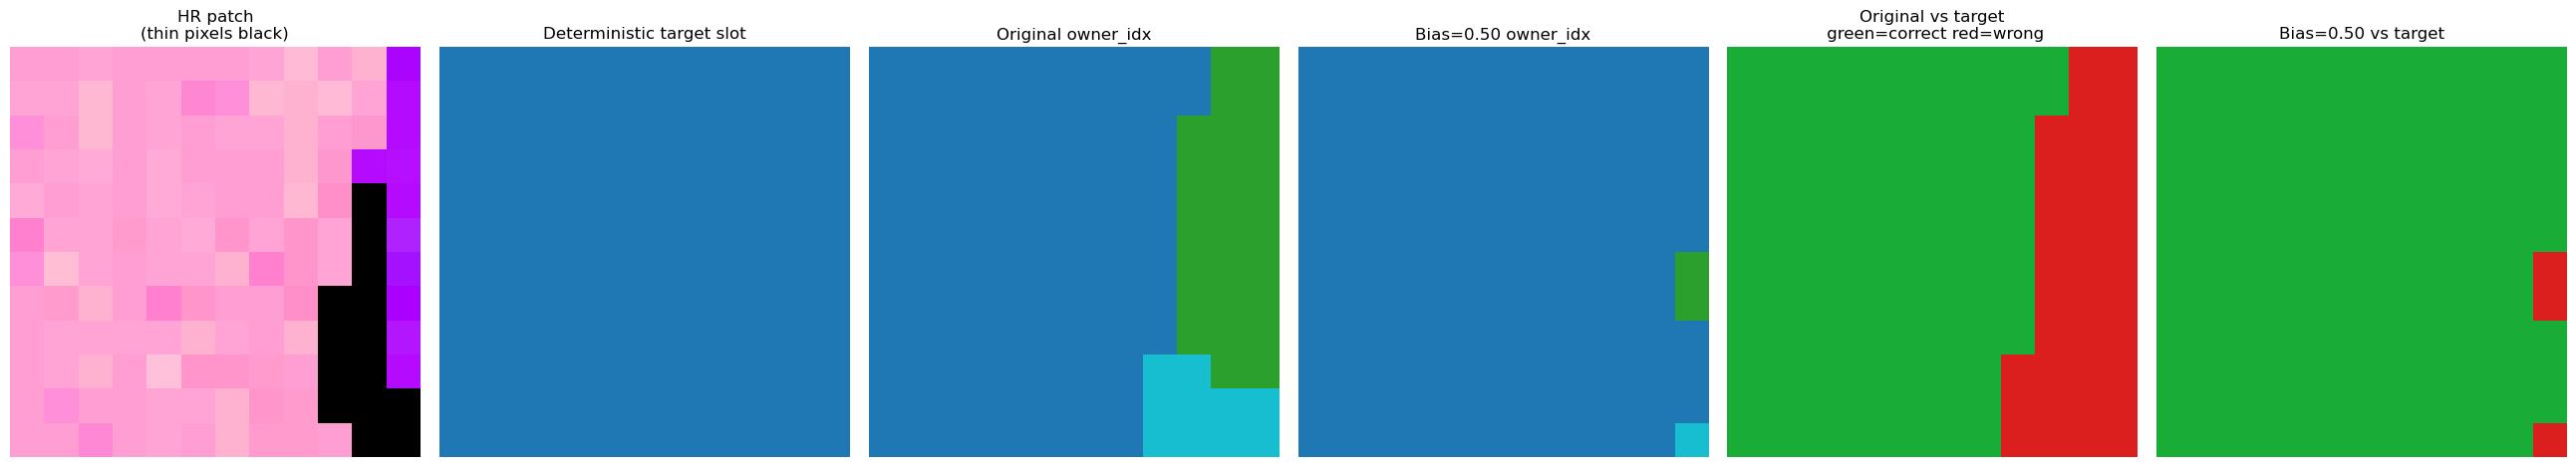

In [91]:
DEMO_SAMPLE_IDX = int(globals().get('DEMO_SAMPLE_IDX', 0))

def _ensure_fix_demo_context(sample_idx: int = 0):
    global _fix_demo_ctx
    ctx = globals().get('_fix_demo_ctx')
    if isinstance(ctx, dict) and int(ctx.get('sample_idx', -1)) == int(sample_idx):
        globals().update(ctx)
        return ctx

    @torch.no_grad()
    def _grid_components_demo(
        quats_hw4,
        sym_ops_quat,
        threshold_deg=2.0,
        connectivity=8,
        miso_chunk=200_000,
    ):
        H, W, _ = quats_hw4.shape
        flat = _normalize_quaternions(quats_hw4.reshape(-1, 4).to(torch.float32))
        sym_mat = _left_mult_matrix_wxyz_batch(_normalize_quaternions(sym_ops_quat.detach().cpu()))
        threshold_rad = float(np.deg2rad(threshold_deg))
        ys = torch.arange(H).view(-1, 1).expand(H, W).reshape(-1)
        xs = torch.arange(W).view(1, -1).expand(H, W).reshape(-1)
        idx = ys * W + xs
        pairs_a, pairs_b = [], []
        if W > 1:
            m = xs < (W - 1)
            pairs_a.append(idx[m]); pairs_b.append(idx[m] + 1)
        if H > 1:
            m = ys < (H - 1)
            pairs_a.append(idx[m]); pairs_b.append(idx[m] + W)
        if connectivity == 8 and H > 1 and W > 1:
            m = (xs < (W - 1)) & (ys < (H - 1))
            pairs_a.append(idx[m]); pairs_b.append(idx[m] + W + 1)
            m = (xs > 0) & (ys < (H - 1))
            pairs_a.append(idx[m]); pairs_b.append(idx[m] + W - 1)
        ea = torch.cat(pairs_a); eb = torch.cat(pairs_b)
        keep_chunks = []
        for s in range(0, ea.numel(), miso_chunk):
            e = min(s + miso_chunk, ea.numel())
            m = _misorientation_angle_sym(flat[ea[s:e]], flat[eb[s:e]], sym_mat)
            keep_chunks.append(m <= threshold_rad)
        keep = torch.cat(keep_chunks)
        ea_k = ea[keep].numpy(); eb_k = eb[keep].numpy()
        n = H * W
        rows = np.concatenate([ea_k, eb_k]); cols = np.concatenate([eb_k, ea_k])
        data = np.ones(rows.shape[0], dtype=np.uint8)
        from scipy.sparse import csr_matrix
        from scipy.sparse.csgraph import connected_components
        g = csr_matrix((data, (rows, cols)), shape=(n, n))
        n_comp, labels = connected_components(g, directed=False)
        return labels.reshape(H, W), int(n_comp)

    def _local_unbatch(x):
        if isinstance(x, torch.Tensor) and x.dim() > 0 and x.shape[0] == 1:
            return x[0]
        return x

    sym_class_local = resolve_symmetry(getattr(cfg, 'symmetry_group', 'Oh'))
    def _ipf_x_local(q_hwc):
        return render_ipf_rgb(q_hwc.numpy().astype(np.float32), sym_class_local, ref_dir='X')

    loader_demo = build_dataloader(
        dataset_root=cfg.dataset_root,
        split=SPLIT,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        preload=False,
        preload_torch=False,
        pin_memory=False,
        take_first=int(sample_idx) + 1,
        seed=int(getattr(cfg, 'seed', 42)),
    )
    batch_demo = None
    for idx_demo, batch_i in enumerate(loader_demo):
        if idx_demo == int(sample_idx):
            batch_demo = batch_i
            break
    if batch_demo is None:
        raise RuntimeError(f'Could not load sample_idx={sample_idx} from split={SPLIT}')

    lr_b_demo, hr_b_demo, _ = _unpack_batch(batch_demo)
    lr_demo = lr_b_demo[0].to(DEVICE, dtype=torch.float32)
    hr_demo = hr_b_demo[0].to(DEVICE, dtype=torch.float32)
    lr_flat_demo, lr_shape_demo = _flatten_quat_chw(lr_demo)
    lr_hwc_demo = _to_hwc_quat_single(lr_demo).detach().cpu()
    hr_hwc_demo = _to_hwc_quat_single(hr_demo).detach().cpu()

    with torch.no_grad():
        feat_lr_demo = model.encode(lr_flat_demo)
        _, hr_shape_demo, aux_demo = model._forward_sr_features(
            lr_quats=lr_flat_demo,
            feat_lr=feat_lr_demo,
            lr_shape=lr_shape_demo,
            return_aux=True,
        )
    aux_demo = {k: _local_unbatch(v) for k, v in aux_demo.items()}

    WINDOW_DEMO = int(model.ocrp.window_size)
    TILE_DEMO = int(model.ocrp.macro_lr_tile_size)
    KMAX_DEMO = int(model.ocrp.kmax_slots)
    UPS_H_DEMO, UPS_W_DEMO = model.ocrp.upsample_factor
    PATCH_H_DEMO, PATCH_W_DEMO = model.ocrp.hr_patch_shape
    GRID_H_DEMO, GRID_W_DEMO = (int(v) for v in aux_demo['support_grid_shape'])
    HR_H_DEMO, HR_W_DEMO = (int(v) for v in hr_shape_demo)
    N_TILES_DEMO = GRID_H_DEMO * GRID_W_DEMO

    yy, xx = np.meshgrid(np.arange(HR_H_DEMO), np.arange(HR_W_DEMO), indexing='ij')
    tile_y = yy // PATCH_H_DEMO
    tile_x = xx // PATCH_W_DEMO
    within_y = yy % PATCH_H_DEMO
    within_x = xx % PATCH_W_DEMO
    tile_idx_hw_demo = (tile_y * GRID_W_DEMO + tile_x).astype(np.int64)
    patch_token_hw_demo = (within_y * PATCH_W_DEMO + within_x).astype(np.int64)

    lr_y = yy // UPS_H_DEMO
    lr_x = xx // UPS_W_DEMO
    tile_center_y = tile_y * TILE_DEMO + (TILE_DEMO // 2)
    tile_center_x = tile_x * TILE_DEMO + (TILE_DEMO // 2)
    center = WINDOW_DEMO // 2
    off_y = lr_y - tile_center_y + center
    off_x = lr_x - tile_center_x + center
    window_node_hw_demo = (off_y * WINDOW_DEMO + off_x).astype(np.int64)

    cluster_ids_np_demo = aux_demo['cluster_ids'].cpu().numpy().astype(np.int64)
    owner_idx_np_demo = aux_demo['owner_idx'].cpu().numpy().astype(np.int64)
    hr_cluster_id_hw_demo = cluster_ids_np_demo[tile_idx_hw_demo, window_node_hw_demo]
    hr_owner_slot_hw_demo = owner_idx_np_demo[tile_idx_hw_demo, patch_token_hw_demo]

    slot_mask_t_demo = aux_demo['slot_mask']
    K_demo = slot_mask_t_demo.shape[1]
    SENTINEL = 99999
    _cids_exp_demo = aux_demo['cluster_ids'].unsqueeze(1).expand(-1, K_demo, -1)
    _masked_demo = torch.where(
        slot_mask_t_demo.bool(),
        _cids_exp_demo,
        torch.full_like(_cids_exp_demo, SENTINEL),
    )
    slot_cluster_label_t_demo = _masked_demo.min(dim=-1).values
    slot_cluster_label_t_demo[slot_cluster_label_t_demo == SENTINEL] = -1
    slot_cluster_label_demo = slot_cluster_label_t_demo.cpu().numpy()

    tile_cluster_slot_demo = {}
    for t in range(N_TILES_DEMO):
        for k in range(K_demo):
            cid = int(slot_cluster_label_demo[t, k])
            if cid >= 0:
                tile_cluster_slot_demo[(t, cid)] = k

    hr_labels_demo, _ = _grid_components_demo(
        hr_hwc_demo,
        model.encoder.sym_ops,
        threshold_deg=2.0,
        connectivity=8,
    )
    uniq_lbl_demo, uniq_cnt_demo = np.unique(hr_labels_demo, return_counts=True)
    thin_area_demo = int(globals().get('THIN_AREA', 200))
    min_area_demo = int(globals().get('MIN_AREA', 4))
    thin_label_set_demo = {
        int(l)
        for l, c in zip(uniq_lbl_demo, uniq_cnt_demo)
        if min_area_demo <= c <= thin_area_demo
    }
    thin_mask_demo = np.isin(hr_labels_demo, list(thin_label_set_demo))

    thin_yy_demo, thin_xx_demo = np.where(thin_mask_demo)
    tile_idx_thin_demo = tile_idx_hw_demo[thin_yy_demo, thin_xx_demo]
    patch_token_thin_demo = patch_token_hw_demo[thin_yy_demo, thin_xx_demo]
    cluster_id_thin_demo = hr_cluster_id_hw_demo[thin_yy_demo, thin_xx_demo]
    owner_slot_thin_demo = hr_owner_slot_hw_demo[thin_yy_demo, thin_xx_demo]
    twin_slot_thin_demo = np.full_like(tile_idx_thin_demo, -1)
    for i, (t, c) in enumerate(zip(tile_idx_thin_demo, cluster_id_thin_demo)):
        twin_slot_thin_demo[i] = tile_cluster_slot_demo.get((int(t), int(c)), -1)
    cluster_survived_demo = twin_slot_thin_demo >= 0
    routed_correctly_demo = cluster_survived_demo & (twin_slot_thin_demo == owner_slot_thin_demo)

    router_target_slot_np_demo = aux_demo['router_target_slot'].cpu().numpy().astype(np.int64)
    router_target_valid_np_demo = aux_demo['router_target_valid'].cpu().numpy().astype(bool)
    router_target_slot_thin_demo = router_target_slot_np_demo[tile_idx_thin_demo, patch_token_thin_demo]
    router_target_valid_thin_demo = router_target_valid_np_demo[tile_idx_thin_demo, patch_token_thin_demo]

    df_thin_demo = pd.DataFrame({
        'y': thin_yy_demo,
        'x': thin_xx_demo,
        'tile': tile_idx_thin_demo,
        'patch_token': patch_token_thin_demo,
        'cluster': cluster_id_thin_demo,
        'twin_slot': twin_slot_thin_demo,
        'owner_slot': owner_slot_thin_demo,
        'cluster_survived': cluster_survived_demo,
        'routed_correctly': routed_correctly_demo,
        'router_target_slot': router_target_slot_thin_demo,
        'router_target_valid': router_target_valid_thin_demo,
    })

    if len(df_thin_demo) == 0:
        raise RuntimeError('No thin features found for the selected sample in fix-demo context.')

    per_tile_demo = df_thin_demo.groupby('tile').agg(
        n_thin_pixels=('y', 'size'),
        cluster_survived_frac=('cluster_survived', 'mean'),
        routed_correct_frac=('routed_correctly', 'mean'),
        router_target_valid_frac=('router_target_valid', 'mean'),
    ).reset_index()
    pure_router_fail_demo = per_tile_demo[per_tile_demo['cluster_survived_frac'] >= 0.999]
    if len(pure_router_fail_demo) > 0:
        target_tile_demo = int(
            pure_router_fail_demo.sort_values(
                ['routed_correct_frac', 'n_thin_pixels'],
                ascending=[True, False],
            ).iloc[0]['tile']
        )
    else:
        target_tile_demo = int(
            per_tile_demo.sort_values(
                ['routed_correct_frac', 'cluster_survived_frac', 'n_thin_pixels'],
                ascending=[True, True, False],
            ).iloc[0]['tile']
        )
    ty_demo, tx_demo = divmod(target_tile_demo, GRID_W_DEMO)
    y0_demo = ty_demo * PATCH_H_DEMO
    y1_demo = min((ty_demo + 1) * PATCH_H_DEMO, HR_H_DEMO)
    x0_demo = tx_demo * PATCH_W_DEMO
    x1_demo = min((tx_demo + 1) * PATCH_W_DEMO, HR_W_DEMO)

    ctx = {
        'sample_idx': int(sample_idx),
        '_unbatch': _local_unbatch,
        'ipf_x': _ipf_x_local,
        'lr': lr_demo,
        'hr': hr_demo,
        'lr_hwc': lr_hwc_demo,
        'hr_hwc': hr_hwc_demo,
        'lr_flat': lr_flat_demo,
        'lr_shape': lr_shape_demo,
        'feat_lr': feat_lr_demo,
        'aux': aux_demo,
        'hr_shape': hr_shape_demo,
        'WINDOW': WINDOW_DEMO,
        'TILE': TILE_DEMO,
        'K_MAX': KMAX_DEMO,
        'UPS_H': UPS_H_DEMO,
        'UPS_W': UPS_W_DEMO,
        'PATCH_H': PATCH_H_DEMO,
        'PATCH_W': PATCH_W_DEMO,
        'GRID_H': GRID_H_DEMO,
        'GRID_W': GRID_W_DEMO,
        'HR_H': HR_H_DEMO,
        'HR_W': HR_W_DEMO,
        'N_TILES': N_TILES_DEMO,
        'cluster_ids_np': cluster_ids_np_demo,
        'owner_idx_np': owner_idx_np_demo,
        'slot_cluster_label': slot_cluster_label_demo,
        'thin_mask': thin_mask_demo,
        'thin_yy': thin_yy_demo,
        'thin_xx': thin_xx_demo,
        'tile_idx_hw': tile_idx_hw_demo,
        'patch_token_hw': patch_token_hw_demo,
        'tile_idx_thin': tile_idx_thin_demo,
        'patch_token_thin': patch_token_thin_demo,
        'owner_slot_thin': owner_slot_thin_demo,
        'router_target_slot_np': router_target_slot_np_demo,
        'router_target_valid_np': router_target_valid_np_demo,
        'router_target_slot_thin': router_target_slot_thin_demo,
        'router_target_valid_thin': router_target_valid_thin_demo,
        'n_thin': int(len(df_thin_demo)),
        'df_thin': df_thin_demo,
        'target_tile': target_tile_demo,
        'ty': ty_demo,
        'tx': tx_demo,
        'y0': y0_demo,
        'y1': y1_demo,
        'x0': x0_demo,
        'x1': x1_demo,
        'hr_patch': hr_hwc_demo[y0_demo:y1_demo, x0_demo:x1_demo],
        'thin_patch': thin_mask_demo[y0_demo:y1_demo, x0_demo:x1_demo],
    }
    _fix_demo_ctx = ctx
    globals().update(ctx)
    return ctx

_ = _ensure_fix_demo_context(sample_idx=DEMO_SAMPLE_IDX)

overall_router_target_acc = (
    (owner_idx_np[router_target_valid_np] == router_target_slot_np[router_target_valid_np]).mean()
    if router_target_valid_np.any() else np.nan
)
thin_router_target_valid = router_target_valid_np[tile_idx_thin, patch_token_thin]
thin_router_target_acc = (
    (owner_slot_thin[thin_router_target_valid] == router_target_slot_thin[thin_router_target_valid]).mean()
    if thin_router_target_valid.any() else np.nan
)
print(f'Current sample: all-token agreement with geometry target  = {100*overall_router_target_acc:.2f} %')
print(f'Current sample: thin-pixel agreement with geometry target = {100*thin_router_target_acc:.2f} %')

BIAS_SWEEP = [0.0, 0.25, 0.50, 1.00]
orig_bias = float(getattr(model.ocrp, 'router_geom_logit_bias', 0.0))
rows = []
try:
    for bias in BIAS_SWEEP:
        model.ocrp.router_geom_logit_bias = float(bias)
        with torch.no_grad():
            _, _, aux_b = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
        aux_b = {k: _unbatch(v) for k, v in aux_b.items()}
        owner_b = aux_b['owner_idx'].cpu().numpy().astype(np.int64)
        target_b = aux_b['router_target_slot'].cpu().numpy().astype(np.int64)
        valid_b = aux_b['router_target_valid'].cpu().numpy().astype(bool)
        overall_acc_b = (
            (owner_b[valid_b] == target_b[valid_b]).mean()
            if valid_b.any() else np.nan
        )
        thin_valid_b = valid_b[tile_idx_thin, patch_token_thin]
        thin_target_b = target_b[tile_idx_thin, patch_token_thin]
        thin_owner_b = owner_b[tile_idx_thin, patch_token_thin]
        thin_acc_valid_b = (
            (thin_owner_b[thin_valid_b] == thin_target_b[thin_valid_b]).mean()
            if thin_valid_b.any() else np.nan
        )
        thin_acc_all_b = (
            (thin_owner_b[thin_valid_b] == thin_target_b[thin_valid_b]).sum() / max(1, n_thin)
            if thin_valid_b.any() else 0.0
        )
        rows.append({
            'bias': bias,
            'overall_valid_token_acc': overall_acc_b,
            'thin_valid_fraction': thin_valid_b.mean() if len(thin_valid_b) > 0 else np.nan,
            'thin_valid_token_acc': thin_acc_valid_b,
            'thin_correct_fraction_of_all_thin': thin_acc_all_b,
        })
finally:
    model.ocrp.router_geom_logit_bias = orig_bias

df_bias = pd.DataFrame(rows)
print(df_bias.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_bias['bias'], df_bias['overall_valid_token_acc'], marker='o', label='all valid tokens')
axes[0].plot(df_bias['bias'], df_bias['thin_valid_token_acc'], marker='o', label='thin valid tokens')
axes[0].set_ylim(0.0, 1.02)
axes[0].set_xlabel('router_geom_logit_bias')
axes[0].set_ylabel('agreement with geometry target')
axes[0].set_title('Geometry-target agreement improves immediately')
axes[0].legend()
axes[1].plot(df_bias['bias'], df_bias['thin_correct_fraction_of_all_thin'], marker='o', color='tab:green')
axes[1].set_ylim(0.0, 1.02)
axes[1].set_xlabel('router_geom_logit_bias')
axes[1].set_ylabel('correct fraction of all thin pixels')
axes[1].set_title('Thin-feature routing recovery without retraining')
plt.tight_layout(); plt.show()

BIAS_DEMO = 0.50
orig_bias = float(getattr(model.ocrp, 'router_geom_logit_bias', 0.0))
try:
    model.ocrp.router_geom_logit_bias = float(BIAS_DEMO)
    with torch.no_grad():
        _, _, aux_demo = model._forward_sr_features(
            lr_quats=lr_flat,
            feat_lr=feat_lr,
            lr_shape=lr_shape,
            return_aux=True,
        )
    aux_demo = {k: _unbatch(v) for k, v in aux_demo.items()}
finally:
    model.ocrp.router_geom_logit_bias = orig_bias

owner_patch_orig = owner_idx_np[target_tile].reshape(PATCH_H, PATCH_W)[: y1 - y0, : x1 - x0]
owner_patch_demo = (
    aux_demo['owner_idx'].cpu().numpy().astype(np.int64)[target_tile]
    .reshape(PATCH_H, PATCH_W)[: y1 - y0, : x1 - x0]
)
target_patch = router_target_slot_np[target_tile].reshape(PATCH_H, PATCH_W)[: y1 - y0, : x1 - x0]
valid_patch = router_target_valid_np[target_tile].reshape(PATCH_H, PATCH_W)[: y1 - y0, : x1 - x0]

agree_orig = valid_patch & (owner_patch_orig == target_patch)
agree_demo = valid_patch & (owner_patch_demo == target_patch)

tile_thin_total = int(thin_patch.sum())
tile_thin_correct_orig = int((agree_orig & thin_patch).sum())
tile_thin_correct_demo = int((agree_demo & thin_patch).sum())
tile_valid_total = int(valid_patch.sum())
tile_valid_correct_orig = int(agree_orig.sum())
tile_valid_correct_demo = int(agree_demo.sum())

print(f'\nTile {target_tile}: geometry bias demo at bias = {BIAS_DEMO:.2f}')
print(f'  valid-token agreement: {tile_valid_correct_orig}/{tile_valid_total} ({100*tile_valid_correct_orig/max(1,tile_valid_total):.1f} %)  ->  '
      f'{tile_valid_correct_demo}/{tile_valid_total} ({100*tile_valid_correct_demo/max(1,tile_valid_total):.1f} %)')
print(f'  thin-pixel agreement : {tile_thin_correct_orig}/{tile_thin_total} ({100*tile_thin_correct_orig/max(1,tile_thin_total):.1f} %)  ->  '
      f'{tile_thin_correct_demo}/{tile_thin_total} ({100*tile_thin_correct_demo/max(1,tile_thin_total):.1f} %)')

def agreement_rgb(valid_mask, agree_mask):
    rgb = np.zeros(valid_mask.shape + (3,), dtype=np.float32)
    rgb[~valid_mask] = [0.92, 0.92, 0.92]
    rgb[valid_mask & ~agree_mask] = [0.86, 0.12, 0.12]
    rgb[agree_mask] = [0.10, 0.68, 0.22]
    return rgb

fig, axes = plt.subplots(1, 6, figsize=(26, 4.5))
axes[0].imshow(ipf_x(hr_patch), interpolation='nearest')
ovl = ipf_x(hr_patch).copy()
ovl[thin_patch] = 0.0
axes[0].imshow(ovl)
axes[0].set_title('HR patch\n(thin pixels black)')
axes[0].axis('off')

axes[1].imshow(target_patch, cmap='tab10', vmin=0, vmax=K_MAX - 1, interpolation='nearest')
axes[1].set_title('Deterministic target slot')
axes[1].axis('off')

axes[2].imshow(owner_patch_orig, cmap='tab10', vmin=0, vmax=K_MAX - 1, interpolation='nearest')
axes[2].set_title('Original owner_idx')
axes[2].axis('off')

axes[3].imshow(owner_patch_demo, cmap='tab10', vmin=0, vmax=K_MAX - 1, interpolation='nearest')
axes[3].set_title(f'Bias={BIAS_DEMO:.2f} owner_idx')
axes[3].axis('off')

axes[4].imshow(agreement_rgb(valid_patch, agree_orig), interpolation='nearest')
axes[4].set_title('Original vs target\n green=correct red=wrong')
axes[4].axis('off')

axes[5].imshow(agreement_rgb(valid_patch, agree_demo), interpolation='nearest')
axes[5].set_title(f'Bias={BIAS_DEMO:.2f} vs target')
axes[5].axis('off')

plt.tight_layout(); plt.show()


## 17 - How to correct the router in training
The notebook evidence now supports a very specific correction path.

This cell also reuses the self-contained demo context from section 16, so you can rerun the fix guidance without depending on the earlier diagnostic sections.

### What to supervise
For each HR token whose underlying LR support node belongs to a surviving slot, the correct router target is already known:
- `router_target_slot`
- `router_target_valid`

So the router can be trained with a direct geometry loss:

`L_total = L_feature + λ_ratio * L_ratio + λ_geom * CE(router_logits, router_target_slot)`

where the CE term is only applied on tokens with `router_target_valid = True`.

### Why this is the right objective
- It trains exactly the failure we measured: **slot survived, router chose the wrong owner**.
- It does not change clustering, slot packing, or the proposal head.
- The inference-time bias sweep already demonstrated that routing is highly recoverable once the right owner is favored.

### Extra ablation worth trying
Disable slot-rank leakage into the router by turning off slot-type metadata for the router input. The slot allocator can remain deterministic; this only removes a shortcut from the router.


In [92]:
if '_ensure_fix_demo_context' not in globals():
    raise RuntimeError('Run cell 38 first; it rebuilds the self-contained fix-demo context.')
_ = _ensure_fix_demo_context(sample_idx=int(globals().get('DEMO_SAMPLE_IDX', 0)))

import json as json

router_geom_loss, router_geom_info = model._router_geom_loss_from_aux(aux)
slot_ratio_loss, slot_ratio_info = model._slot_ratio_loss_from_aux(aux)

print('Current sample losses / diagnostics:')
print(f"  router_geom_unweighted : {float(router_geom_info['router_geom_unweighted']):.6f}")
print(f"  router_geom_acc        : {100*float(router_geom_info['router_geom_acc']):.2f} %")
print(f"  slot_ratio_unweighted  : {float(slot_ratio_info['slot_ratio_unweighted']):.6f}")
print(f"  slot_ratio_l1          : {float(slot_ratio_info['slot_ratio_l1']):.6f}")

suggested_cfg = {
    'ocrp_router_geom_loss_weight': 0.10,
    'ocrp_router_use_slot_type_meta': False,
    'ocrp_router_geom_logit_bias': 0.00,
    'ocrp_slot_ratio_loss_weight': float(getattr(cfg, 'ocrp_slot_ratio_loss_weight', 0.0)),
}
print('\nSuggested first retrain config:')
print(json.dumps(suggested_cfg, indent=2))

ablation_plan = pd.DataFrame([
    {
        'experiment': 'Probe existing checkpoint',
        'goal': 'Verify ownership is recoverable without retraining',
        'settings': 'router_geom_logit_bias in {0.25, 0.5, 1.0}',
        'success_criterion': 'thin-pixel routing rises sharply, slot dropping unchanged',
    },
    {
        'experiment': 'Retrain A',
        'goal': 'Add explicit geometry supervision only',
        'settings': 'ocrp_router_geom_loss_weight=0.10, use_slot_type_meta=True',
        'success_criterion': 'misrouting falls substantially at similar feature loss',
    },
    {
        'experiment': 'Retrain B',
        'goal': 'Remove slot-rank shortcut',
        'settings': 'ocrp_router_geom_loss_weight=0.10, use_slot_type_meta=False',
        'success_criterion': 'lower slot-rank starvation, especially on slots 2-5',
    },
    {
        'experiment': 'Retrain C (optional)',
        'goal': 'Address residual geometry deficits',
        'settings': 'keep geom loss; add richer slot meta later only if needed',
        'success_criterion': 'incremental gain after router ownership is fixed',
    },
])
print('\nRecommended ablation plan:')
print(ablation_plan.to_string(index=False))

print('\nWhat success should look like when you rerun this notebook after retraining:')
print('- Fraction of thin pixels misrouted should fall much more than fraction dropped.')
print('- Aggregate all-token geometry-target agreement should move upward from ~90%.')
print('- Thin-pixel agreement should move up sharply from ~61%.')
print('- zero_token_valid_rate for slots 2-5 should drop meaningfully.')


Current sample losses / diagnostics:
  router_geom_unweighted : 0.371747
  router_geom_acc        : 90.62 %
  slot_ratio_unweighted  : 0.001215
  slot_ratio_l1          : 0.027904

Suggested first retrain config:
{
  "ocrp_router_geom_loss_weight": 0.1,
  "ocrp_router_use_slot_type_meta": false,
  "ocrp_router_geom_logit_bias": 0.0,
  "ocrp_slot_ratio_loss_weight": 0.05
}

Recommended ablation plan:
               experiment                                               goal                                                    settings                                         success_criterion
Probe existing checkpoint Verify ownership is recoverable without retraining                  router_geom_logit_bias in {0.25, 0.5, 1.0} thin-pixel routing rises sharply, slot dropping unchanged
                Retrain A             Add explicit geometry supervision only  ocrp_router_geom_loss_weight=0.10, use_slot_type_meta=True    misrouting falls substantially at similar feature loss
            

## 18 - Conclusion

The notebook now answers the core question more cleanly than the original draft:

1. **Top-K slot dropping is real, but it is not the dominant failure mode in this checkpoint.** The aggregate numbers show a small dropped tail and a much larger misrouting term.
2. **The dominant bottleneck is router ownership, not feature synthesis.** In the measured failures, the thin-feature slot often survives, but the router still assigns the HR token to a different surviving slot.
3. **The current checkpoint does not directly feed raw slot mass to the router.** With `ocrp_router_slot_mass_power = 0.0`, the router-side mass channel is flattened to `1` for every valid slot. So the strongest explanation is not “mass dominates the router”; it is “the router lacks an explicit per-token geometric teacher and can lean on slot-rank metadata instead.”
4. **The most diagnostic evidence is low-rank slot starvation.** If slots 3-5 are valid but frequently get zero routed HR tokens, while thin-feature correctness falls sharply with slot rank, the router is using a shortcut that disadvantages low-rank surviving slots.
5. **The correction path is geometric, not allocator-centric.** If a light deterministic geometry bias sharply improves router-target agreement on the existing checkpoint, then the model already has the representational ingredients; the missing piece is router supervision / prior, not a larger slot budget.

### Recommended correction path

1. **Add an explicit router geometry objective.**
   The natural target already exists: for each HR token, route to the slot containing the underlying LR support node after slot packing. This is exactly what `router_target_slot` / `router_target_valid` now expose.
2. **Optionally disable slot-rank leakage into the router.**
   The slot allocator can keep deterministic ordering, but the router does not need the slot-type one-hot if it is learning to suppress low-rank slots as a shortcut.
3. **Use a small inference-time geometry bias as a probe before retraining.**
   If routing improves immediately, that is strong evidence that the issue is in ownership priors / supervision rather than proposal quality.
4. **Only then revisit slot budget or richer slot metadata.**
   Raising `kmax_slots` and adding anisotropy descriptors may still help, but the notebook's measured bottleneck says they are secondary compared with router ownership.

### Residual caveat

This notebook uses **thin connected components** as a proxy for thin twins. That is good enough to localize the current bottleneck, but if you later attach explicit twin labels, rerun the exact same attribution pipeline with those labels for the final materials-science claim.
